# Assignment 3 - Milestone I: Natural Language Processing
# Task 1 - Basic Text Pre-processing
#### Student Name: Nam Nguyen Phuong, Tran Ophelie Manon, Matt Do, Yoshita Sarin
#### Student ID: 3941773, 3968993, 4232487, 4225113
### Environment: Python 3 and Jupyter notebook
## Libraries used
| Library | Purpose |
|---|---|
| `pandas` | Reading the CSV file and saving output files |
| `numpy` | Computing review length statistics |
| `nltk.RegexpTokenizer` | Tokenising each review using the assignment pattern |
| `nltk.stem.WordNetLemmatizer` | Converting words to their base form |
| `itertools.chain` | Flattening nested token lists for vocabulary operations |
| `collections.Counter` | Counting word and document frequencies |
| `collections.defaultdict` | Efficient document frequency computation |
| `html` | Decoding HTML entities (e.g. `&amp;` -> `&`) |
| `contractions` | Expanding contractions (e.g. `don't` -> `do not`) |
| `emoji` | Detecting and removing emoji characters |
| `langdetect` | Detecting the language of each review |
| `unicodedata` | Normalising Unicode and removing diacritics |
| `pathlib` | File path handling |

---
## Introduction

### What this notebook does

This notebook covers **Task 1** of the assignment: cleaning and pre-processing approximately
61,000 cosmetics and beauty product reviews so they are ready for downstream machine-learning
tasks. We focus exclusively on the `review_text` column - the free-text narrative written
by each reviewer.

### What we produce at the end

| Output file | Content |
|---|---|
| `processed.csv` | The original dataset with `review_text` replaced by the cleaned, space-joined token string |
| `vocab.txt` | The alphabetically sorted unigram vocabulary in `word:index` format, indices starting at 0 |

### Pipeline at a glance

The 16 steps below run in order. **Required** steps come straight from the assignment brief.
**Additional** steps go further to remove noise that would otherwise pollute the vocabulary
without breaking any required behaviour.

| # | Step | Type |
|---|---|---|
| 1 | Load and inspect the data | Required |
| 2 | Check for missing values, duplicates, and non-English reviews | Additional |
| 3 | Analyse special characters (tags, digits, emojis, HTML entities, etc.) | Additional |
| 4 | Decode HTML entities (`&amp;` -> `&`) | Additional |
| 5 | Expand contractions (`don't` -> `do not`) | Additional |
| 6 | Normalise repeated characters (`loooove` -> `loove`) | Additional |
| 7 | Remove `@tags`, `#hashtags`, brackets, URLs, digits, diacritics, emojis, Unicode | Required |
| 8 | Tokenise with `r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?"` and lowercase | Required |
| 9 | Remove tokens shorter than 2 characters | Required |
| 10 | Remove stop words (`stopwords_en.txt`) | Required |
| 11 | Lemmatise using POS-aware WordNet lemmatizer | Additional |
| 12 | Second stopword removal pass (catches lemma-induced stopwords) | Additional |
| 13 | Verify token lists end-to-end (format, case, stopwords, digits, etc.) | Additional |
| 14 | Remove words that appear only once (term frequency = 1) | Required |
| 15 | Remove the top 20 most frequent words by document frequency | Required |
| 16 | Save `processed.csv` and `vocab.txt` | Required |

### How the notebook is laid out

To make the notebook easy to follow, everything sits under two top-level sections:

* **Section 1** runs the entire pre-processing pipeline (loading, cleaning, tokenising,
  vocabulary refinement, and end-to-end verification).
* **Section 2** writes the final `processed.csv` and `vocab.txt` to disk and prints
  the closing summary.

---
## Importing libraries

The next cell imports everything used in the rest of the notebook and `pip installs` the
two non-default libraries (`emoji`, `contractions`) so the notebook is self-contained on
a fresh environment.

In [1]:
from collections import Counter, defaultdict
from html import unescape
from itertools import chain
from pathlib import Path
import re
import string
import unicodedata
import contractions as contractions_lib
import emoji
import nltk
import numpy as np
import pandas as pd
import regex
from nltk import RegexpTokenizer
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet',                        quiet=True)
nltk.download('omw-1.4',                        quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

True

---
## 1. Pre-processing Pipeline

This is the main body of the notebook. It loads the raw reviews, audits them, applies
every cleaning step, and produces the final cleaned token lists ready for output.

### 1.1 Data Loading & Inspection

Before any cleaning we want to be sure of three things:

1. The CSV loads correctly and matches the size we expect.
2. We know which columns matter and which are metadata.
3. We have spotted any obvious data-quality problems (missing values, duplicates,
   non-English text) that could distort frequency-based filters later.

This section is purely observational - no data is transformed.

#### 1.1.1 Loading the data

We read the raw CSV into a pandas DataFrame using a comma separator and the first row as
the header. The path is relative to the notebook folder.

In [2]:
REVIEWS_PATH = 'cosmetics_beauty_products_reviews.csv'
raw_reviews_df = pd.read_csv(REVIEWS_PATH, sep=',', header=0)

#### 1.1.2 Initial data inspection

We print the shape, look at the first/last rows, and group the columns logically so we
understand the structure before touching anything.

In [3]:
raw_reviews_df.shape

(61284, 15)

##### 1.1.2.1 Shape and DataFrame metadata

The dataset contains:

- **61,284 reviews** (rows)
- **15 columns** (one of them - `review_text` - is what we transform)

Recording these baseline numbers is important because every later step either drops
reviews (deduplication) or reduces tokens within reviews (cleaning, filtering).
Knowing where we started lets us sanity-check where we end up.

In [4]:
raw_reviews_df.head()

,product_id,brand_name,review_id,review_title,review_text,author,review_date,review_rating,is_a_buyer,product_title,price,avg_product_rating,product_rating_count,product_tags,product_url
0,781070,Olay,16752142,Worth buying 50g one,Works as it claims. Could see the difference f...,Ashton Dsouza,23/01/2021 15:17,5.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
1,781070,Olay,14682550,Best cream to start ur day,It does what it claims . Best thing is it smoo...,Amrit Neelam,07/09/2020 15:30,5.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
2,781070,Olay,15618995,perfect for summers dry for winters,I have been using this product for months now....,Sanchi Gupta,13/11/2020 12:24,4.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
3,781070,Olay,13474509,Not a moisturizer,"i have an oily skin, while this whip acts as a...",Ruchi Shah,14/06/2020 11:56,3.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
4,781070,Olay,16338982,Average,It's not that good. Please refresh try for oth...,Sukanya Sarkar,22/12/2020 15:24,2.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...


In [5]:
raw_reviews_df.tail()

,product_id,brand_name,review_id,review_title,review_text,author,review_date,review_rating,is_a_buyer,product_title,price,avg_product_rating,product_rating_count,product_tags,product_url
61279,1044490,Herbal Essences,17769058,Good,I use this thrice a week. Has helped me in mak...,Radhesh,12/04/2021 13:28,5.0,True,Herbal Essences Aloe & Eucalyptus Shampoo For ...,525,4.3,512,FEATURED,https://www.nykaa.com/herbal-essences-potent-a...
61280,1044490,Herbal Essences,17766838,Great,This shampoo has a amazing fragnance and textu...,Shalini Sirohi,12/04/2021 11:47,5.0,True,Herbal Essences Aloe & Eucalyptus Shampoo For ...,525,4.3,512,FEATURED,https://www.nykaa.com/herbal-essences-potent-a...
61281,1044490,Herbal Essences,17765866,Really mild and nice,"Used it for the first time, feels really fresh...",Sana kanted,12/04/2021 10:58,5.0,True,Herbal Essences Aloe & Eucalyptus Shampoo For ...,525,4.3,512,FEATURED,https://www.nykaa.com/herbal-essences-potent-a...
61282,1044490,Herbal Essences,17761057,Amazing product!,One of the best shampoo which are sulphate and...,neeru chouhan,11/04/2021 21:44,5.0,True,Herbal Essences Aloe & Eucalyptus Shampoo For ...,525,4.3,512,FEATURED,https://www.nykaa.com/herbal-essences-potent-a...
61283,4633369,Colorbar,25987603,Not good,It is so irritating so bad i don't like this much,Mssuhv,20/06/2022 17:41,2.0,False,Colorbar Mogra Mist - Scent Of An India Temple...,417,1.5,2,NaN,https://www.nykaa.com/colorbar-mogra-mist-scen...


##### 1.1.2.2 Column breakdown

The 15 columns naturally fall into four groups. Only `review_text` is transformed by this
notebook; everything else is preserved as-is for downstream tasks.

**Review content**

| Column | Description |
|---|---|
| `review_id` | Unique identifier per review |
| `review_title` | Short headline written by the reviewer |
| `review_text` | Full body text - the only column we pre-process |
| `author` | Reviewer identity |
| `review_date` | Date of submission |
| `review_rating` | Numeric score (1-5) |
| `is_a_buyer` | Verified-purchase flag |

**Product identity**

| Column | Description |
|---|---|
| `product_id` | Unique product key |
| `product_title` | Product name |
| `brand_name` | Brand |
| `product_url` | Source link |

**Pricing & aggregate ratings**

| Column | Description |
|---|---|
| `price` | Product price at the time of review |
| `avg_product_rating` | Mean rating across all reviews of the product |
| `product_rating_count` | Total number of ratings the product has received |

**Taxonomy**

| Column | Description |
|---|---|
| `product_tags` | Category/tag labels associated with the product |

##### 1.1.2.3 Key observations

Five things from the column breakdown matter for later tasks:

1. `review_text` is the only column we transform.
2. `review_rating` provides a ground-truth label for any supervised modelling.
3. `is_a_buyer` lets us filter for verified buyers if we want a higher-quality subset.
4. `brand_name` and `product_tags` enable slice-level analysis (per brand, per category).
5. `review_date` enables time-series analysis of sentiment trends.

> **&#8594; Observation:** Because Tasks 2 and 3 rely on these metadata columns,
> our pipeline must keep every column intact. Only `review_text` content changes.

---
#### 1.1.3 Data Quality Checks

We run three quick checks before any text transformation:

1. **Missing values** - reviews with no text at all.
2. **Exact duplicates** - reviews with identical text.
3. **Non-English content** - reviews written in other languages.

Each check protects the rest of the pipeline. If duplicates were left in, frequency counts
in Section 1.3 would be skewed; if `NaN` values were left in, the cleaning helpers would
crash; non-English content is a diagnostic only and is naturally handled later by the
Unicode normalisation step.

##### 1.1.3.1 Missing values in `review_text`

`NaN` (pandas' "missing" marker) is not a string, so the cleaning helpers would raise an
exception if we left it in. We replace it with an empty string `""` - the helpers then
return zero tokens for that row, which is the desired behaviour.

> **&#8594; Observation:** Only 9 reviews (about 0.015% of the dataset) have no text.
> They are too few to skew anything, but we still keep them - their metadata may be
> useful in Tasks 2 and 3, even if their token list is empty.

In [6]:
missing_count = raw_reviews_df['review_text'].isna().sum()
print(f"Missing review_text values: {missing_count:,} ({missing_count / len(raw_reviews_df):.3%})")
raw_reviews_df[raw_reviews_df['review_text'].isna()]

Missing review_text values: 9 (0.015%)


,product_id,brand_name,review_id,review_title,review_text,author,review_date,review_rating,is_a_buyer,product_title,price,avg_product_rating,product_rating_count,product_tags,product_url
5470,564436,Nykaa Cosmetics,22242576,Excellent product for,NaN,lipika gharami,01/01/2022 13:57,5.0,True,Nykaa Lash Talk False Eyelash - Major Length,149,3.9,11381,NaN,https://www.nykaa.com/nykaa-lash-talk-major-le...
6224,551016,Nykaa Cosmetics,19113046,Its just perfect,NaN,Aisha Roy,22/06/2021 19:04,5.0,True,Nykaa Strobe & Glow Liquid Highlighter,559,4.1,8720,NaN,https://www.nykaa.com/nykaa-strobe-glow-liquid...
36204,1139,Lakme,20752769,Super,NaN,Kayalvizhi S,05/10/2021 20:07,5.0,True,Lakme True Wear Nail Color,125,4.1,11663,NaN,https://www.nykaa.com/lakme-true-wear-nail-col...
36430,1139,Lakme,19379470,Love it,NaN,Anindita Haldar,11/07/2021 16:44,4.0,True,Lakme True Wear Nail Color,125,4.1,11663,NaN,https://www.nykaa.com/lakme-true-wear-nail-col...
43566,692836,Kay Beauty,26172743,Supper mat,NaN,namrata,27/06/2022 12:48,5.0,True,Kay Beauty Quick Dry Liquid Eyeliner,399,4.4,9552,NaN,https://www.nykaa.com/kay-beauty-eye-stylist-l...
50371,5093150,Kay Beauty,24926826,Cosy coral,NaN,Stuti Gupta,12/05/2022 01:59,4.0,True,Kay Beauty Creme Blush,799,4.5,2010,"FEATURED, BESTSELLER",https://www.nykaa.com/kay-beauty-creme-blush-s...
50396,5093150,Kay Beauty,24643028,Sweetheart pink,NaN,Stuti Gupta,06/05/2022 16:13,4.0,True,Kay Beauty Creme Blush,799,4.5,2010,"FEATURED, BESTSELLER",https://www.nykaa.com/kay-beauty-creme-blush-s...
52323,1229442,Kay Beauty,21445677,Loved it,NaN,priyanka daimary,19/11/2021 21:14,5.0,True,Kay Beauty Hydrating Foundation,900,4.4,4577,"FEATURED, BESTSELLER",https://www.nykaa.com/kay-beauty-hydrating-fou...
54178,1080669,Kay Beauty,24260037,Damn good product,NaN,Ankita S,23/04/2022 15:06,4.0,True,Kay Beauty Matte Blush,639,4.5,4619,NaN,https://www.nykaa.com/kay-beauty-matte-blush/p...


In [7]:
raw_reviews_df['review_text'] = raw_reviews_df['review_text'].fillna('')
raw_reviews_df['review_text_original'] = raw_reviews_df['review_text'].copy()  # snapshot for later spot-check
assert raw_reviews_df['review_text'].isna().sum() == 0
print("No missing values remain in review_text.")

No missing values remain in review_text.


##### 1.1.3.2 Duplicate reviews

Duplicates inflate word frequencies. If the same review appears 50 times, every word in
it gets counted 50 times, which would mislead both the rare-word filter (Section 1.3.1)
and the top-20 filter (Section 1.3.2). We detect duplicates by exact string match on
`review_text` and keep the first occurrence.

> **&#8594; Observation:** We use `keep='first'` so the earliest copy of any duplicated
> text survives. We then call `reset_index(drop=True)` so row positions stay contiguous -
> later code iterates by integer index, and contiguous indices keep that simple.

In [8]:
n_dupes = raw_reviews_df.duplicated(subset=['review_text'], keep='first').sum()
print(f"Exact duplicate reviews : {n_dupes:,} ({n_dupes / len(raw_reviews_df):.2%})")
if n_dupes > 0:
    print("\nSample of most-duplicated texts:")
    dupe_texts = (
        raw_reviews_df[raw_reviews_df.duplicated(subset=['review_text'], keep=False)]
        .groupby('review_text').size()
        .sort_values(ascending=False)
        .head(5)
    )
    for text, count in dupe_texts.items():
        print(f"  [{count}×] {repr(str(text)[:100])}")

Exact duplicate reviews : 1,452 (2.37%)

Sample of most-duplicated texts:
  [134×] 'Good'
  [117×] 'Nice'
  [38×] 'Good product'
  [37×] 'Loved it'
  [29×] 'Love it'


In [9]:
raw_reviews_df = (
    raw_reviews_df
    .drop_duplicates(subset=['review_text'], keep='first')
    .reset_index(drop=True)
)
print(f"Reviews after deduplication: {len(raw_reviews_df):,}")

Reviews after deduplication: 59,832


##### 1.1.3.3 Non-English reviews

Our stop-word list and lemmatizer are English-only. A review in Hindi or Arabic cannot
benefit from either. We use `langdetect` on a 5,000-row sample (not the full dataset, to
keep the diagnostic fast) just to **measure** how prevalent non-English text is.

We deliberately do **not** filter non-English reviews here. The Unicode normalisation
step in the cleaning pipeline (Section 1.2.2.13) drops any character outside the
ASCII range, so reviews written entirely in non-Latin scripts naturally produce empty
token lists at tokenisation. The problem solves itself further down.

> **&#8594; Observation:** The sample-based estimate is purely diagnostic - it informs
> the report, but the cleaning pipeline does not consume the detected language.

In [10]:
import sys
!{sys.executable} -m pip install langdetect

In [11]:
try:
    from langdetect import detect, LangDetectException
    def detect_language(text: str) -> str:
        try:
            return detect(str(text)) if str(text).strip() else 'unknown'
        except LangDetectException:
            return 'unknown'
    sample = raw_reviews_df['review_text'].sample(min(5000, len(raw_reviews_df)), random_state=42)
    lang_counts = sample.apply(detect_language).value_counts()
    print("Language distribution (sample of 5,000 reviews):")
    print(lang_counts.head(10).to_string())
    non_en_pct = (1 - lang_counts.get('en', 0) / len(sample)) * 100
    print(f"\nEstimated non-English: {non_en_pct:.1f}%")
except ImportError:
    print("langdetect not installed. Run: pip install langdetect")

Language distribution (sample of 5,000 reviews):
review_text
en    4878
af      23
ro      13
tl      10
fr       9
da       8
it       8
so       7
no       7
et       7

Estimated non-English: 2.4%


---
### 1.2 Text Preprocessing

This section is the heart of the pipeline. It is divided into five sub-sections that
follow a natural workflow:

| Sub-section | Purpose |
|------|-----|
| 1.2.1     | **Audit** the raw text to see which noise types are actually present (evidence) |
| 1.2.2     | **Define** one helper function per cleaning step (implementation) |
| 1.2.3     | **Assemble** the helpers into a single ordered cleaning pipeline |
| 1.2.4     | Apply post-tokenisation steps that operate on **token lists** (short words, stop words, lemmatisation) |
| 1.2.5     | **Verify** that every step produced the expected result |

The split between 1.2.1 and 1.2.2 is deliberate: 1.2.1 explains **why** each cleaning step
is needed (with evidence from the data); 1.2.2 explains **how** the corresponding helper
function implements it. Reading them as a pair gives the full justification.

#### 1.2.1 Special Character Analysis

Before writing any cleaning code we look at the raw text and confirm which noise types
appear. This audit is what justifies every helper function in Section 1.2.2 - if a noise
type isn't present in the data we don't waste time handling it (for example, no curly
brackets ever appear, so we skip that step).

For each noise type below we count how many reviews are affected and show a few real
examples before deciding what to do.

##### 1.2.1.1 `@tags`

`@username` mentions are a holdover from social-media style writing and point to a
specific person, not the product.

> **&#8594; Why remove them:** The username inside an `@tag` is unique per person and will
> never accumulate enough frequency to survive the rare-word filter. It also has no
> sentiment about the product. Replacing the `@tag` with a single space ensures
> neighbouring words are not glued together when the tag is removed.

In [12]:
has_tags = raw_reviews_df['review_text'].str.contains(r'@\w+', regex=True, na=False).sum()
print(f"Reviews with @tags    : {has_tags:,} ({has_tags / len(raw_reviews_df):.2%})")
tagged = raw_reviews_df[raw_reviews_df['review_text'].str.contains(r'@\w+', regex=True, na=False)]
print("\nFirst 3 examples:")
for i, text in enumerate(tagged['review_text'].head(3), 1):
    print(f"  {i}. {text[:150]}")

Reviews with @tags    : 16 (0.03%)

First 3 examples:
  1. Its smooth, makes me look alluring and chic.. Love@MASABA
  2. I can't believe that is is only @150?? Soo good! Love it!!
  3. I love this compact.. is a best compact from @nykaa thnque so much for creating such a beautiful product.


##### 1.2.1.2 `#hashtags`

Hashtags are common in product reviews (`#love`, `#mustbuy`). The word after the `#` is
usually meaningful; the `#` itself is the problem.

> **&#8594; Why replace `#` with a space:** The tokenizer regex `[a-zA-Z]+(?:[-'][a-zA-Z]+)?`
> only matches letters. A literal `#` would force the tokenizer to break at that point and
> the word after would still be captured - but if `#` is glued to the previous word
> (`great#love`), both halves can be lost. Replacing `#` with a space cleanly separates
> the words on either side.

In [13]:
has_hashtags = raw_reviews_df['review_text'].str.contains(r'#\w+', regex=True, na=False).sum()
print(f"Reviews with #hashtags: {has_hashtags:,} ({has_hashtags / len(raw_reviews_df):.2%})")
hashtagged = raw_reviews_df[raw_reviews_df['review_text'].str.contains(r'#\w+', regex=True, na=False)]
print("\nFirst 3 examples:")
for i, text in enumerate(hashtagged['review_text'].head(3), 1):
    print(f"  {i}. {text[:150]}")

Reviews with #hashtags: 31 (0.05%)

First 3 examples:
  1. Apply it n sleep wake up with no pimple face #happy girls
  2. The product is amazing... its a beautiful Rose Gold shade & will suit light to medium skin tone my shade ref is Mac NC 17 & maybelline fit me 118 this
  3. This lipstick shade is super classy, it's like a natural lip colour. Can put this shade regularly too. Nice one . JUST LOVED IT. NYKAA. #satisfiedwith


##### 1.2.1.3 Digits

Reviews often contain digits: product codes (`SKU 12345`), prices (`$19.99`), star
ratings inside the text (`I'd give it 5 stars`), or ages (`I'm 30`).

> **&#8594; Why remove them:** None of these convey product sentiment in a way a model can
> generalise from. Removing them up front means the tokenizer pattern (which only allows
> letters) does not have to deal with mixed alphanumeric tokens like `5stars`.

In [14]:
has_digits = raw_reviews_df['review_text'].str.contains(r'\d', regex=True, na=False).sum()
print(f"Reviews with digits   : {has_digits:,} ({has_digits / len(raw_reviews_df):.2%})")
digit_reviews = raw_reviews_df[raw_reviews_df['review_text'].str.contains(r'\d', regex=True, na=False)]
print("\nFirst 3 examples:")
for i, text in enumerate(digit_reviews['review_text'].head(3), 1):
    print(f"  {i}. {text[:150]}")

Reviews with digits   : 6,019 (10.06%)

First 3 examples:
  1. 3in1 benifits, helps reduces dark spots and wrinkles.
  2. This is the first time am reviewing or commending a product. I must say this to all!! Olay products are really superb. In that white radiance advance 
  3. First time user. Exceptionally less quantity as it appears. This packet can be used for a maximum of 7 days. Costly.


##### 1.2.1.4 Punctuation marks

Almost every review has punctuation. The danger of leaving it in is **token sticking** -
if someone writes `great.Highly` (no space after the full stop), the tokenizer would
treat that as two completely separate things from `great Highly`.

> **&#8594; Why replace punctuation with spaces (rather than removing it):** Replacement
> preserves word boundaries. We deliberately keep `-` and `'` because the assignment
> tokenizer pattern allows hyphenated words (`anti-aging`) and contractions (`don't`)
> as single tokens.

In [15]:
punct_pattern = '[' + re.escape(string.punctuation) + ']'
has_punct = raw_reviews_df['review_text'].str.contains(punct_pattern, regex=True, na=False).sum()
print(f"Reviews with punctuation: {has_punct:,} ({has_punct / len(raw_reviews_df):.2%})")
punct_counts = {
    p: raw_reviews_df['review_text'].str.contains(re.escape(p), regex=True, na=False).sum()
    for p in string.punctuation
}
print("\nTop 10 punctuation marks:")
for p, c in sorted(punct_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  '{p}': {c:,} reviews ({c / len(raw_reviews_df):.1%})")

Reviews with punctuation: 51,558 (86.17%)

Top 10 punctuation marks:
  '.': 46,030 reviews (76.9%)
  ',': 15,081 reviews (25.2%)
  ''': 13,141 reviews (22.0%)
  '!': 6,431 reviews (10.7%)
  '-': 3,472 reviews (5.8%)
  '?': 1,792 reviews (3.0%)
  ')': 944 reviews (1.6%)
  '&': 899 reviews (1.5%)
  '(': 727 reviews (1.2%)
  ':': 580 reviews (1.0%)


##### 1.2.1.5 Diacritics (accent marks)

Words like `café`, `naïve`, and `crème` appear in a small number of reviews.

> **&#8594; Why strip diacritics:** Without stripping, `café` and `cafe` would be two
> different vocabulary entries even though they're the same word. Stripping
> diacritics merges them into one entry and prevents the same root word from
> fragmenting across multiple variants.

In [16]:
def has_diacritics(text):
    if pd.isna(text): return False
    return any(unicodedata.combining(c) for c in unicodedata.normalize('NFD', str(text)))
diac_count = raw_reviews_df['review_text'].apply(has_diacritics).sum()
print(f"Reviews with diacritics: {diac_count:,} ({diac_count / len(raw_reviews_df):.2%})")
diac_reviews = raw_reviews_df[raw_reviews_df['review_text'].apply(has_diacritics)]
print("\nFirst 3 examples:")
for i, text in enumerate(diac_reviews['review_text'].head(3), 1):
    print(f"  {i}. {text[:150]}")

Reviews with diacritics: 139 (0.23%)

First 3 examples:
  1. Review after 1 month of use- It is a thick cream which looks like a soufflé. it instantly absorbs but that is exactly what i dont like about it. becau
  2. Very expensive and skin looks oily no tint effect it’s better buy Lakmé BB cream
  3. This doesn’t remove nail polish AT ALL It’s a joke in the name of a nail polish remover. Go with the normal Lakmé one. Don’t waste money on this


##### 1.2.1.6 Extra whitespace

Some reviews contain double spaces, tabs, or newlines.

> **&#8594; Why no explicit step is needed:** The tokenizer regex splits on any
> whitespace boundary, so multiple consecutive whitespace characters are treated
> identically to a single space. Running an explicit normaliser would be redundant.

In [17]:
def has_extra_whitespace(text):
    if pd.isna(text): return False
    return bool(re.search(r'  |\t|\n|\r', str(text)))
ws_count = raw_reviews_df['review_text'].apply(has_extra_whitespace).sum()
multiple_spaces = raw_reviews_df['review_text'].str.contains(r'  ',    regex=True, na=False).sum()
has_tabs        = raw_reviews_df['review_text'].str.contains(r'\t',    regex=True, na=False).sum()
has_newlines    = raw_reviews_df['review_text'].str.contains(r'\n|\r', regex=True, na=False).sum()
print(f"Reviews with extra whitespace : {ws_count:,} ({ws_count / len(raw_reviews_df):.2%})")
print(f"  Multiple spaces             : {multiple_spaces:,}")
print(f"  Tab characters              : {has_tabs:,}")
print(f"  Newlines                    : {has_newlines:,}")

Reviews with extra whitespace : 0 (0.00%)
  Multiple spaces             : 0
  Tab characters              : 0
  Newlines                    : 0


##### 1.2.1.7 Round brackets

Round brackets `(` `)` typically wrap asides or technical specs
(e.g. `it's great (especially the smell)`).

> **&#8594; Why strip the brackets but keep the words inside:** The text inside the
> brackets is meaningful. The brackets themselves can glue adjacent words together
> if punctuation handling misses them, so we remove them explicitly.

In [18]:
has_rb = raw_reviews_df['review_text'].str.contains(r'[()]', regex=True, na=False).sum()
print(f"Reviews with round brackets: {has_rb:,} ({has_rb / len(raw_reviews_df):.2%})")
rb_reviews = raw_reviews_df[raw_reviews_df['review_text'].str.contains(r'[()]', regex=True, na=False)]
print("\nFirst 3 examples:")
for i, text in enumerate(rb_reviews['review_text'].head(3), 1):
    print(f"  {i}. {text[:150]}")

Reviews with round brackets: 989 (1.65%)

First 3 examples:
  1. Was expecting better miniaturisation. I bought it as an under eye cream (I don't use anti-ageing since I am only 20). If it couldn't moisturize the sk
  2. I had dark circles and puffy eyes for years,After using this cream for 1 month(2 times a day) I can see the difference. Dark circles and puffiness com
  3. Gives positive result. Can go for it. (As per my Mom)


##### 1.2.1.8 Curly brackets

> **&#8594; Result:** No curly brackets `{` `}` appear anywhere in the dataset, so no
> action is taken. We still ran the check so we can document that we considered this
> noise type.

In [19]:
has_cb = raw_reviews_df['review_text'].str.contains(r'[{}]', regex=True, na=False).sum()
print(f"Reviews with curly brackets: {has_cb:,} ({has_cb / len(raw_reviews_df):.2%})")

Reviews with curly brackets: 0 (0.00%)


##### 1.2.1.9 Square brackets

> **&#8594; Result:** No square brackets `[` `]` appear in the dataset, so no action is
> taken. The check is run for completeness.

In [20]:
has_sb = raw_reviews_df['review_text'].str.contains(r'[\[\]]', regex=True, na=False).sum()
print(f"Reviews with square brackets: {has_sb:,} ({has_sb / len(raw_reviews_df):.2%})")

Reviews with square brackets: 3 (0.01%)


##### 1.2.1.10 URLs

A small number of reviews contain hyperlinks pointing to other products or external pages.

> **&#8594; Why remove URLs:** A URL contains digits, slashes, dots, and unique tokens
> that would never repeat across reviews. Even if a fragment of a URL passed the
> tokenizer, it would be removed by the rare-word filter later. Stripping the whole URL
> upfront keeps the tokenizer focused on real prose.

In [21]:
has_urls = raw_reviews_df['review_text'].str.contains(r'https?://\S+|www\.\S+', regex=True, na=False).sum()
print(f"Reviews with URLs: {has_urls:,} ({has_urls / len(raw_reviews_df):.2%})")
url_reviews = raw_reviews_df[raw_reviews_df['review_text'].str.contains(r'https?://\S+|www\.\S+', regex=True, na=False)]
print("\nFirst 3 examples:")
for i, text in enumerate(url_reviews['review_text'].head(3), 1):
    print(f"  {i}. {text[:150]}")

Reviews with URLs: 15 (0.03%)

First 3 examples:
  1. Just wowwww.... Soooo good pigmentation.. Lasts so longg... Definitely a must buy... The nude shade is so beautiful✨✨✨✨😍😍😍😍❤❤❤❤
  2. Madras kapi.. Nude in brown color family.. Pigmentation is a wowww.. Day wear fav for me
  3. Its stays longer and it a beautiful colour , i loved it being jude shade lover. https://www.maybelline.co.in/search-results?searchTerm=compact


##### 1.2.1.11 Emojis

Beauty reviews are full of emojis (`😍 💄 ✨`). We had to choose between **removing**
them and **converting** them to text descriptions.

> **&#8594; Decision: remove, do not convert.** Converting an emoji like `😍` produces
> generic words such as `smiling` and `face`. But genuine reviews already use those
> exact words (e.g. *"this product broke out my face"*), so we'd no longer be able to
> tell whether `face` came from real text or from an emoji. That ambiguity would
> mislead any downstream model. Removing emojis keeps every word in the vocabulary
> tied to real product language.

In [22]:
def has_emoji_chars(text):
    if pd.isna(text): return False
    return any(
        unicodedata.category(c) == 'So'
        or (0x1F300 <= ord(c) <= 0x1FAFF)
        or (0x2600 <= ord(c) <= 0x27BF)
        for c in str(text)
    )
emoji_count = raw_reviews_df['review_text'].apply(has_emoji_chars).sum()
print(f"Reviews with emojis: {emoji_count:,} ({emoji_count / len(raw_reviews_df):.2%})")
emoji_reviews = raw_reviews_df[raw_reviews_df['review_text'].apply(has_emoji_chars)]
print("\nFirst 3 examples:")
for i, text in enumerate(emoji_reviews['review_text'].head(3), 1):
    print(f"  {i}. {text[:150]}")

Reviews with emojis: 3,400 (5.68%)

First 3 examples:
  1. 👍
  2. Reduce dark circles and fresh eyes Mind-blowing work 😘
  3. It does makes my under eye area soft by adding moisture , It kinda gives lightt cocealer effect after application!! It doesn't fade away ur panda 🐼 ey


##### 1.2.1.12 All unique emoji symbols

For completeness we list every distinct emoji symbol that appears in the dataset
(including skin-tone modifiers, ZWJ-joined sequences, regional flags, etc.).

> **&#8594; Why this matters:** Confirming the **set** of emojis present lets us be
> sure that the `emoji.replace_emoji` library covers every variant we have, including
> the more unusual sequences.

In [23]:
_emoji_range = (
    "\U0001F300-\U0001F5FF\U0001F600-\U0001F64F\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F\U0001F780-\U0001F7FF\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF\U0001FA70-\U0001FAFF☀-⛿✀-➿"
)
_emoji_full_pattern = regex.compile(
    rf"(?:(?:[\U0001F1E6-\U0001F1FF]{{2}})|(?:[0-9#*]️?⃣)|"
    rf"(?:[{_emoji_range}]️?[\U0001F3FB-\U0001F3FF]?(?:‍[{_emoji_range}]️?[\U0001F3FB-\U0001F3FF]?)*))"
)
def extract_emojis(text):
    return _emoji_full_pattern.findall(str(text)) if not pd.isna(text) else []
all_unique_emojis = sorted(set(
    e for lst in raw_reviews_df['review_text'].apply(extract_emojis) for e in lst
))
print(f"Total unique emojis found: {len(all_unique_emojis)}")
print("\nAll unique emojis:")
print(" ".join(all_unique_emojis))

Total unique emojis found: 250

All unique emojis:
5️⃣ ☀️ ☂️ ☘️ ☝ ☠ ☹ ☹️ ☺ ☺️ ♡ ♥ ♥️ ♾ ⚡ ⚡️ ⛱️ ✅ ✈️ ✌ ✌️ ✌🏻 ✌🏼 ✓ ✔ ✔️ ✨ ✨️ ✴️ ❣ ❣️ ❤ ❤️ ❤️‍🔥 ❤️‍🩹 ➖ 🌈 🌙 🌚 🌝 🌞 🌟 🌷 🌸 🌹 🌺 🌻 🌼 🍅 🍉 🍏 🍑 🍓 🍫 🍭 🍷 🎀 🎁 🎈 🎉 🎊 🎗 🎨 🐢 🐥 🐼 👀 👁 👄 👅 👈🏻 👉🏻 👌 👌🏻 👌🏼 👌🏿 👍 👍🏻 👍🏼 👍🏽 👍🏾 👍🏿 👎 👎🏻 👎🏼 👎🏽 👏 👏🏻 👏🏼 👑 👛 👜 👝 💁 💁🏻‍♀️ 💃 💃🏻 💄 💅 💅🏻 💋 💌 💐 💓 💔 💕 💖 💗 💘 💙 💚 💛 💜 💝 💞 💟 💣 💥 💦 💫 💯 💰 💵 💸 📦 📰 📸 🔅 🔥 🖌 🖤 🗞️ 😀 😁 😂 😃 😄 😅 😇 😉 😊 😋 😌 😍 😎 😏 😐 😑 😒 😓 😔 😕 😖 😘 😙 😚 😛 😜 😞 😟 😠 😡 😢 😣 😤 😥 😩 😫 😬 😭 😯 😲 😳 😶 😻 🙀 🙁 🙂 🙃 🙄 🙆‍♀️ 🙆🏻‍♀️ 🙈 🙊 🙋🏻‍♀️ 🙌 🙌🏻 🙌🏼 🙏 🙏🏻 🚚 🚫 🛅 🛍 🟣 🟤 🤌 🤌🏻 🤍 🤎 🤐 🤑 🤓 🤔 🤕 🤗 🤘 🤘🏻 🤞 🤞🏻 🤟 🤟🏼 🤢 🤣 🤤 🤦 🤦‍♀️ 🤦🏻‍♀️ 🤧 🤩 🤪 🤬 🤭 🤮 🤷 🤷🏻‍♀️ 🥀 🥂 🥑 🥥 🥦 🥰 🥲 🥳 🥴 🥺 🦄 🦋 🧈 🧖🏻‍♀️ 🧚‍♀️ 🧛🏻‍♀️ 🧡 🧢 🧱 🧴 🧿 🪄 🫶🏻 🫶🏼


##### 1.2.1.13 Non-Latin Unicode characters

Some reviews contain characters from non-Latin scripts (Devanagari, Arabic, CJK ideographs)
or mathematical symbols.

> **&#8594; What `normalize_unicode` does to them:** NFKD decomposition converts
> "fancy Latin" variants to plain ASCII (e.g. mathematical bold italic `𝙄𝙩'𝙨` -> `It's`).
> Anything that has no ASCII equivalent is silently dropped. The end result is that any
> review written entirely in a non-Latin script ends up with no tokens, which is exactly
> what we want.

In [24]:
def contains_non_latin(text):
    if pd.isna(text): return False
    return any(
        ord(c) > 127 and unicodedata.category(c) not in ('So', 'Mn')
        for c in str(text)
    )
unicode_count = raw_reviews_df['review_text'].apply(contains_non_latin).sum()
print(f"Reviews with non-Latin unicode: {unicode_count:,} ({unicode_count / len(raw_reviews_df):.2%})")
non_latin_chars = {
    c for text in raw_reviews_df['review_text'] if not pd.isna(text)
    for c in str(text)
    if ord(c) > 127 and unicodedata.category(c) not in ('So', 'Mn')
}
print(f"\nUnique non-Latin characters: {len(non_latin_chars)}")
print("Examples (first 15):")
for c in list(non_latin_chars)[:15]:
    try:    name = unicodedata.name(c)
    except ValueError: name = '[No name]'
    print(f"  '{c}' (U+{ord(c):04X}) - {name}")

Reviews with non-Latin unicode: 3,859 (6.45%)

Unique non-Latin characters: 58
Examples (first 15):
  '𝙮' (U+1D66E) - MATHEMATICAL SANS-SERIF BOLD ITALIC SMALL Y
  '‘' (U+2018) - LEFT SINGLE QUOTATION MARK
  '·' (U+00B7) - MIDDLE DOT
  '»' (U+00BB) - RIGHT-POINTING DOUBLE ANGLE QUOTATION MARK
  'ĺ' (U+013A) - LATIN SMALL LETTER L WITH ACUTE
  '’' (U+2019) - RIGHT SINGLE QUOTATION MARK
  '🏾' (U+1F3FE) - EMOJI MODIFIER FITZPATRICK TYPE-5
  '𝙣' (U+1D663) - MATHEMATICAL SANS-SERIF BOLD ITALIC SMALL N
  '𝙞' (U+1D65E) - MATHEMATICAL SANS-SERIF BOLD ITALIC SMALL I
  '𝙥' (U+1D665) - MATHEMATICAL SANS-SERIF BOLD ITALIC SMALL P
  '´' (U+00B4) - ACUTE ACCENT
  'à' (U+00E0) - LATIN SMALL LETTER A WITH GRAVE
  '⋅' (U+22C5) - DOT OPERATOR
  '​' (U+200B) - ZERO WIDTH SPACE
  'Ó' (U+00D3) - LATIN CAPITAL LETTER O WITH ACUTE


##### 1.2.1.14 HTML entities

Web-scraped data often contains HTML entities such as `&amp;`, `&lt;`, and `&#39;`.

> **&#8594; Why decode entities first:** The order of cleaning steps matters. If we
> don't decode entities first, `don&#39;t` will not match the contractions library's
> patterns (which expect a real apostrophe). Decoding `&#39;` to `'` early lets the
> contraction expander turn it into `do not`.

In [25]:
has_html = raw_reviews_df['review_text'].str.contains(r'&\w+;|&#\d+;', regex=True, na=False).sum()
print(f"Reviews with HTML entities: {has_html:,} ({has_html / len(raw_reviews_df):.2%})")
html_reviews = raw_reviews_df[raw_reviews_df['review_text'].str.contains(r'&\w+;|&#\d+;', regex=True, na=False)]
print("\nFirst 3 examples:")
for i, text in enumerate(html_reviews['review_text'].head(3), 1):
    print(f"  {i}. {text[:150]}")

Reviews with HTML entities: 0 (0.00%)

First 3 examples:


##### 1.2.1.15 Contractions

Contractions like `don't`, `can't`, and `it's` are kept as single tokens by the regex
tokenizer (because the pattern allows the apostrophe). The problem is that
`WordNetLemmatizer` cannot lemmatise them - `don't` would just stay as `don't` in the
vocabulary forever, and the negation would be locked inside it.

> **&#8594; Why expand contractions before tokenisation:** Expansion turns `don't` into
> `do not`. After that, `not` is removed by the stop-word filter and `do` is lemmatised
> normally. Without expansion, the negation never reaches the stop-word filter.

In [26]:
_contraction_re = re.compile(
    r"\b\w+n't\b|\b(I'm|I've|I'll|I'd|you're|you've|can't|won't|don't|"
    r"doesn't|didn't|isn't|aren't|wasn't|weren't|it's|that's|there's|"
    r"they're|we're|what's|who's|would've|could've|should've)\b",
    re.IGNORECASE,
)
has_contractions = raw_reviews_df['review_text'].str.contains(_contraction_re, regex=True, na=False).sum()
print(f"Reviews with contractions: {has_contractions:,} ({has_contractions / len(raw_reviews_df):.2%})")
contr_reviews = raw_reviews_df[raw_reviews_df['review_text'].str.contains(_contraction_re, regex=True, na=False)]
print("\nFirst 3 examples:")
for i, text in enumerate(contr_reviews['review_text'].head(3), 1):
    print(f"  {i}. {text[:150]}")

/var/folders/52/c8stjft56gj2nf93ldl5c1c00000gn/T/ipykernel_69791/2137618967.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_contractions = raw_reviews_df['review_text'].str.contains(_contraction_re, regex=True, na=False).sum()


Reviews with contractions: 12,602 (21.06%)


/var/folders/52/c8stjft56gj2nf93ldl5c1c00000gn/T/ipykernel_69791/2137618967.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contr_reviews = raw_reviews_df[raw_reviews_df['review_text'].str.contains(_contraction_re, regex=True, na=False)]



First 3 examples:
  1. It's not that good. Please refresh try for other products
  2. Olay just works wonders for me. This combo is the best. My skin feels so soft, hydrated, I often get compliments about my skin. Just follow a good die
  3. Nothing works. It's advertisement is good and got tempted to use these products. I used both day & night cream and no results whatsoever. I have pigme


##### 1.2.1.16 Repeated characters

Beauty reviewers love emphasis: `loooove`, `sooooo good`, `amazinggg`.

> **&#8594; Why collapse 3+ repeats to 2 (not 1):** Collapsing all the way to 1 would
> damage real English words that legitimately have a doubled letter (`book`, `tomorrow`,
> `success`). Collapsing to 2 preserves those real doubled letters while still merging
> exaggerated variants - `loove` is the same surviving form regardless of whether the
> original was `loooove`, `looooove`, or `looooooove`.

In [27]:
has_repeated = raw_reviews_df['review_text'].str.contains(r'(.)\1{2,}', regex=True, na=False).sum()
print(f"Reviews with repeated chars: {has_repeated:,} ({has_repeated / len(raw_reviews_df):.2%})")
rep_reviews = raw_reviews_df[raw_reviews_df['review_text'].str.contains(r'(.)\1{2,}', regex=True, na=False)]
print("\nFirst 3 examples:")
for i, text in enumerate(rep_reviews['review_text'].head(3), 1):
    print(f"  {i}. {text[:150]}")

Reviews with repeated chars: 7,701 (12.87%)

First 3 examples:
  1. dz product z best for dry skin ...one of olay representative ...suggest me to buy dz..she said its all skin type .but please oily skin type ..don buys
  2. The smell is amaazing!!!! My mother loves it... She is using it over a month now... The results are starting to show.... Smooth skin... And a glowy to
  3. Nice...


/var/folders/52/c8stjft56gj2nf93ldl5c1c00000gn/T/ipykernel_69791/2065972358.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_repeated = raw_reviews_df['review_text'].str.contains(r'(.)\1{2,}', regex=True, na=False).sum()
/var/folders/52/c8stjft56gj2nf93ldl5c1c00000gn/T/ipykernel_69791/2065972358.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  rep_reviews = raw_reviews_df[raw_reviews_df['review_text'].str.contains(r'(.)\1{2,}', regex=True, na=False)]


---
#### 1.2.2 Preprocessing Helper Functions

Now we implement one focused helper function for each transformation justified in
Section 1.2.1. Every helper:

* Does **exactly one thing** - this makes the pipeline (Section 1.2.3) read like a list of
  named operations rather than a wall of code.
* **Defends against bad input** by returning an empty string for `None` or non-string
  values, so a missing review never crashes the pipeline.
* Has a **clear docstring** so a reader can understand what it does without reading the body.

The functions below are presented in roughly the order in which they will be applied.

##### 1.2.2.1 Decode HTML entities

Implementation: `html.unescape` from the standard library converts every HTML entity
in one pass. This handles named entities (`&amp;` -> `&`), numeric entities
(`&#39;` -> `'`), and named character references in a single call - we don't have to
maintain our own table of mappings.

In [28]:
def decode_html_entities(text: object) -> str:
    """Decode HTML entities. e.g. &amp; -> &, &#39; -> '"""
    if text is None:
        return ""
    return unescape(str(text))

##### 1.2.2.2 Expand contractions

Implementation: the third-party `contractions` library handles the long tail of
English contractions (including unusual cases like `y'all`, `would've`, `o'clock`).
Using it instead of a hand-rolled regex avoids missing edge cases.

In [29]:
def expand_contractions(text: object) -> str:
    """Expand English contractions. e.g. don't -> do not, can't -> cannot"""
    if text is None:
        return ""
    return contractions_lib.fix(str(text))

##### 1.2.2.3 Normalise repeated characters

Implementation: a single regex `(.)\1{2,}` matches any character repeated 3 or more
times, and the substitution `\1\1` keeps just two of them. The regex is compiled
once at module level (`_REPEATED_CHARS`) for performance.

In [30]:
_REPEATED_CHARS = re.compile(r'(.)\1{2,}')
def normalize_repeated_chars(text: object) -> str:
    """Collapse 3+ consecutive identical characters to 2. e.g. loooove -> loove"""
    if text is None:
        return ""
    return _REPEATED_CHARS.sub(r'\1\1', str(text))

##### 1.2.2.4 Lowercase

Implementation: Python's built-in `str.lower()`. Lowercasing is required by the brief
and is also the last string-level step before tokenisation - putting it last guarantees
that no earlier transformation accidentally re-introduces uppercase characters.

In [31]:
def lowercase(text: object) -> str:
    """Convert text to lowercase so Skin and skin are treated as the same word."""
    if text is None:
        return ""
    return str(text).lower()

##### 1.2.2.5 Remove `@tags`

Implementation: regex `@\w+` matches an `@` followed by one or more word characters.
We replace each match with a single space (not the empty string) so words on either
side of the removed tag stay separated.

In [32]:
def replace_tags(text: object) -> str:
    """Remove @username mentions, replacing them with a space."""
    if text is None:
        return ""
    return re.sub(r'@\w+', ' ', str(text))

##### 1.2.2.6 Replace `#hashtags`

Implementation: a plain `str.replace('#', ' ')` is enough - we only need to remove the
`#` symbol, not the word after it. The word that followed will then be tokenised normally.

In [33]:
def replace_hashtags(text: object) -> str:
    """Replace # with a space to free the keyword from the symbol."""
    if text is None:
        return ""
    return str(text).replace('#', ' ')

##### 1.2.2.7 Remove digits

Implementation: regex `\d+` matches any run of digits and replaces it with the empty
string. We use `+` instead of `*` so we don't waste work matching empty positions.

In [34]:
def remove_digits(text: object) -> str:
    """Remove all digit characters."""
    if text is None:
        return ""
    return re.sub(r'\d+', '', str(text))

##### 1.2.2.8 Remove punctuation

Implementation: we build a `str.maketrans` translation table that maps every character
in `string.punctuation`, **except** `-` and `'`, to a space. `str.translate` then does
the substitution in a single C-level pass, which is faster than a Python loop. The
exclusion of `-` and `'` is what keeps hyphenated words and contractions intact.

In [35]:
_PUNCT_TABLE = str.maketrans(
    string.punctuation.replace('-', '').replace("'", ""),
    ' ' * len(string.punctuation.replace('-', '').replace("'", "")),
)
def remove_punctuation(text: object) -> str:
    """Replace punctuation with spaces, preserving hyphens and apostrophes."""
    if text is None:
        return ""
    return str(text).translate(_PUNCT_TABLE)

##### 1.2.2.9 Remove diacritics

Implementation: NFD Unicode decomposition splits a character like `é` into the base
letter `e` plus a combining acute accent. We then drop every combining mark
(those for which `unicodedata.combining(c)` is non-zero), leaving the bare ASCII letter.

In [36]:
def remove_diacritics(text: object) -> str:
    """Strip accent marks. e.g. café -> cafe, naïve -> naive"""
    if text is None:
        return ""
    return ''.join(
        c for c in unicodedata.normalize('NFD', str(text))
        if not unicodedata.combining(c)
    )

##### 1.2.2.10 Remove round brackets

Implementation: two `str.replace` calls, one for `(` and one for `)`. We replace with
the empty string because the words inside the brackets are already separated from
neighbouring text by spaces.

In [37]:
def remove_round_brackets(text: object) -> str:
    """Strip ( and ) characters."""
    if text is None:
        return ""
    return str(text).replace('(', '').replace(')', '')

##### 1.2.2.11 Remove URLs

Implementation: regex `https?://\S+|www\.\S+` matches both `http(s)://...` and
`www....` URLs, where `\S+` greedily consumes everything up to the next whitespace.
We replace the match with the empty string.

In [38]:
def remove_urls(text: object) -> str:
    """Remove http://, https://, and www. links."""
    if text is None:
        return ""
    return re.sub(r'https?://\S+|www\.\S+', '', str(text))

##### 1.2.2.12 Remove emojis

Implementation: we use `emoji.replace_emoji(text, replace='')` from the third-party
`emoji` library. This library knows about every emoji code point (including ZWJ
sequences and skin-tone modifiers) so we don't have to maintain our own ranges.

In [39]:
def remove_emojis(text: object) -> str:
    """Remove all emoji characters from text."""
    if text is None:
        return ""
    return emoji.replace_emoji(str(text), replace='')

##### 1.2.2.13 Normalise Unicode

Implementation: NFKD decomposition (similar to NFD but also splits compatibility
characters like ligatures), followed by an `encode('ascii', 'ignore').decode('ascii')`
round-trip that drops anything outside the ASCII range. This is the final safety net -
anything left after the previous steps that is still non-ASCII gets stripped here.

In [40]:
def normalize_unicode(text: object) -> str:
    """Normalise Unicode to ASCII. e.g. 𝙄𝙩'𝙨 -> It's. Non-ASCII chars are dropped."""
    if text is None:
        return ""
    return (
        unicodedata.normalize('NFKD', str(text))
        .encode('ascii', 'ignore')
        .decode('ascii')
    )

##### 1.2.2.14 Statistics helper

A small utility that prints unique-word count, total-word count, review count, and
average review length on a list of token lists. We call it after every major step in
Section 1.2.4 so we can track how each transformation reshapes the corpus.

> **&#8594; Observation:** This is purely diagnostic - it does not modify the data.

In [41]:
def stats_print(tk_reviews: list[list[str]]) -> None:
    """Print a summary of vocabulary and review length statistics."""
    words        = list(chain.from_iterable(tk_reviews))
    unique_words = set(words)
    lens         = [len(r) for r in tk_reviews]
    print(f"Number of unique words         : {len(unique_words):,}")
    print(f"Total number of words          : {len(words):,}")
    if words:
        print(f"Word variety (unique/total)    : {len(unique_words)/len(words):.5f}")
    else:
        print("Word variety (unique/total)    : 0.0")
    print(f"Number of reviews              : {len(tk_reviews):,}")
    if lens:
        print(f"Average review length          : {np.mean(lens):.2f}")
        print(f"Longest review (in words)      : {int(np.max(lens))}")
        print(f"Shortest review (in words)     : {int(np.min(lens))}")
        print(f"Standard deviation of length   : {np.std(lens):.2f}")

In [42]:
# --- Pipeline audit utility ---------------------------------------------------
# Records token counts at each major step so we can produce a single summary
# table at the end of Section 1.3 showing how much each step removed.
_audit_rows: list[tuple[str, int, int, int]] = []

def audit(stage: str, reviews: list[list[str]]) -> None:
    """Record token / type / empty-review counts at a labelled pipeline stage."""
    total = sum(len(r) for r in reviews)
    types = len({w for r in reviews for w in r})
    empty = sum(1 for r in reviews if not r)
    _audit_rows.append((stage, total, types, empty))
    print(f"  [{stage:<32}] tokens={total:>10,}  types={types:>7,}  empty={empty:>5,}")


---
#### 1.2.3 Cleaning Pipeline & Tokenisation

We now combine the helpers from Section 1.2.2 into one end-to-end function called
`clean_and_tokenise`. The order matters - putting steps in the wrong order would leak
noise into the output.

Four ordering rules drive the design:

| Rule | Reason |
|---|---|
| HTML decoding **before** contraction expansion | so `&#39;` -> `'` happens first, letting `don&#39;t` match the contraction library |
| Contraction expansion **before** punctuation removal | so `don't` -> `do not` happens before the `'` is stripped |
| Emojis **before** Unicode normalisation | so emoji characters are stripped cleanly before NFKD touches them |
| Lowercase **last** | so no earlier step accidentally re-introduces uppercase characters |

The final ordered sequence is:

| Step | Function | What it does |
|---|---|---|
| 1 | `decode_html_entities` | `&amp;` -> `&`, `&#39;` -> `'` |
| 2 | `expand_contractions` | `don't` -> `do not` |
| 3 | `normalize_repeated_chars` | `loooove` -> `loove` |
| 4 | `replace_tags` | Remove `@username` |
| 5 | `replace_hashtags` | `#` -> space |
| 6 | `remove_round_brackets` | Strip `(` `)` |
| 7 | `remove_emojis` | Strip all emoji characters |
| 8 | `remove_urls` | Remove `http(s)://...` and `www....` links |
| 9 | `remove_digits` | Remove all numbers |
| 10 | `remove_diacritics` | `café` -> `cafe` |
| 11 | `normalize_unicode` | Non-ASCII -> ASCII / drop |
| 12 | `remove_punctuation` | Replace punct with spaces (keeps `-` `'`) |
| 13 | `lowercase` | Standardise casing |
| 14 | `RegexpTokenizer` | Split using `r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?"` |

> **&#8594; Observation:** Right after tokenisation the unique-word count is at its
> highest. Every following step can only reduce it. The numbers we record here are the
> baseline against which Sections 1.2.4 and 1.3 compare.

In [43]:
PATTERN   = r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?"
tokenizer = RegexpTokenizer(PATTERN)
def clean_and_tokenise(text: str) -> list[str]:
    """Run the full cleaning pipeline on one review and return its token list."""
    text = decode_html_entities(text)
    text = expand_contractions(text)
    text = normalize_repeated_chars(text)
    text = replace_tags(text)
    text = replace_hashtags(text)
    text = remove_round_brackets(text)
    text = remove_emojis(text)
    text = remove_urls(text)
    text = remove_digits(text)
    text = remove_diacritics(text)
    text = normalize_unicode(text)
    text = remove_punctuation(text)
    text = lowercase(text)
    return tokenizer.tokenize(text)
tk_reviews = [clean_and_tokenise(r) for r in raw_reviews_df['review_text'].tolist()]
stats_print(tk_reviews)
audit("after tokenisation", tk_reviews)


Number of unique words         : 16,117
Total number of words          : 1,324,897
Word variety (unique/total)    : 0.01216
Number of reviews              : 59,832
Average review length          : 22.14
Longest review (in words)      : 451
Shortest review (in words)     : 0
Standard deviation of length   : 19.09
  [after tokenisation              ] tokens= 1,324,897  types= 16,117  empty=   40


##### 1.2.3.1 Pipeline verification

Once the pipeline has run over every review we automate-check the cleaned strings
to confirm each transformation actually happened. The next code cell counts how many
reviews still contain each of the noise types we tried to remove.

The specific checks are:

| # | Check | Expected result |
|---|---|---|
| 1 | Any `@tags` left | 0 reviews |
| 2 | Any `#` characters left | 0 reviews |
| 3 | Any round brackets `(` `)` left | 0 reviews |
| 4 | Any URLs left | 0 reviews |
| 5 | Any digits left | 0 reviews |
| 6 | Any uppercase letters left | 0 reviews |
| 7 | Any HTML entities left | 0 reviews |

If any check returns a non-zero count it means a step was skipped or applied in the
wrong order, and we'd investigate before proceeding.

In [44]:
print("=== Cleaning Pipeline Verification ===\n")
cleaned_texts = [' '.join(tokens) for tokens in tk_reviews]
checks = {
    "@tags removed"          : sum(bool(re.search(r'@\w+', t)) for t in cleaned_texts),
    "#hashtags replaced"     : sum('#' in t for t in cleaned_texts),
    "Round brackets removed" : sum('(' in t or ')' in t for t in cleaned_texts),
    "URLs removed"           : sum(bool(re.search(r'https?://|www\.', t)) for t in cleaned_texts),
    "Digits removed"         : sum(bool(re.search(r'\d', t)) for t in cleaned_texts),
    "Diacritics removed"     : sum(
        any(unicodedata.combining(c) for c in unicodedata.normalize('NFD', t))
        for t in cleaned_texts
    ),
    "Punctuation removed"    : sum(
        any(c in string.punctuation.replace('-', '').replace("'", "") for c in t)
        for t in cleaned_texts
    ),
    "Lowercase applied"      : sum(t != t.lower() for t in cleaned_texts),
    "Tokens are words only"  : sum(
        not all(re.fullmatch(r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?", w) for w in tokens)
        for tokens in tk_reviews if tokens
    ),
}
all_passed = True
for check, violations in checks.items():
    passed = violations == 0
    status = "✅ PASS" if passed else f"❌ FAIL ({violations:,} reviews)"
    print(f"  {status}  {check}")
    if not passed:
        all_passed = False
print(f"\n{'✅ All checks passed!' if all_passed else '❌ Some checks failed.'}")
print(f"Total reviews checked: {len(tk_reviews):,}")

=== Cleaning Pipeline Verification ===

  ✅ PASS  @tags removed
  ✅ PASS  #hashtags replaced
  ✅ PASS  Round brackets removed
  ✅ PASS  URLs removed
  ✅ PASS  Digits removed
  ✅ PASS  Diacritics removed
  ✅ PASS  Punctuation removed
  ✅ PASS  Lowercase applied
  ✅ PASS  Tokens are words only

✅ All checks passed!
Total reviews checked: 59,832


---
#### 1.2.4 Post-Tokenisation Preprocessing

The helpers in Section 1.2.2 worked on **strings**. The remaining steps work on
**lists of tokens**, because they only make sense after the text has been split.

Following the order required by the brief:

| Sub-section | Step |
|---|---|
| 1.2.4.1 | Inspect reviews that produced zero tokens |
| 1.2.4.2 | Drop tokens shorter than 2 characters |
| 1.2.4.3 | Drop stop words from `stopwords_en.txt` |
| 1.2.4.4 | Lemmatise (POS-aware) |
| 1.2.4.5 | Re-apply the short-word filter to catch any 1-char lemmas |
| 1.2.4.6 | Re-apply the stop-word filter to catch any new stop-word lemmas |

The frequency-based filters (rare words, top-20) are larger conceptual steps and live
in Section 1.3, after the verification in Section 1.2.5.

##### 1.2.4.1 Handling empty reviews

After tokenisation, some reviews have **no tokens at all**. These are reviews whose
original text was entirely digits, URLs, emojis, or non-ASCII symbols - everything was
stripped and nothing remained.

> **&#8594; Decision:** We do **not** drop these reviews from the dataset. They appear
> as empty strings in `processed.csv`. This keeps the row count stable, preserves the
> alignment between `processed.csv` and the original input row by row, and keeps the
> metadata (rating, brand, etc.) usable in Tasks 2 and 3.

In [45]:
empty_indices = [i for i, r in enumerate(tk_reviews) if not r]
print(f"Empty reviews after tokenisation: {len(empty_indices)} ({len(empty_indices)/len(tk_reviews):.2%})")
for i in empty_indices[:5]:
    original = raw_reviews_df['review_text'].iloc[i]
    print(f"\n[{i}] Original : {repr(str(original)[:120])}")
    print(f"     Tokens   : {clean_and_tokenise(original) or '(empty)'}")
stats_print(tk_reviews)

Empty reviews after tokenisation: 40 (0.07%)

[41] Original : '👍'
     Tokens   : (empty)

[239] Original : '42'
     Tokens   : (empty)

[463] Original : '❤️'
     Tokens   : (empty)

[469] Original : '🥰😍😍😍'
     Tokens   : (empty)

[1801] Original : '❤️❤️❤️❤️❤️'
     Tokens   : (empty)
Number of unique words         : 16,117
Total number of words          : 1,324,897
Word variety (unique/total)    : 0.01216
Number of reviews              : 59,832
Average review length          : 22.14
Longest review (in words)      : 451
Shortest review (in words)     : 0
Standard deviation of length   : 19.09


##### 1.2.4.2 Removing short words (length < 2)

The brief mandates dropping tokens shorter than 2 characters. These are almost always
single-letter leftovers (`a`, `i`, `u`) or one-letter abbreviations that got separated
from their context.

> **&#8594; Observation:** This step removes a relatively small number of unique tokens
> but a large number of token occurrences, because letters like `a` and `i` are very
> common. The unique-vocabulary cost is tiny; the corpus-cleanliness benefit is large.

In [46]:
MIN_WORD_LENGTH = 2
def filter_short_words(
    tokenized_reviews: list[list[str]],
    min_length: int = MIN_WORD_LENGTH,
) -> list[list[str]]:
    """Remove tokens shorter than min_length characters."""
    return [[w for w in review if len(w) >= min_length] for review in tokenized_reviews]
tk_reviews = filter_short_words(tk_reviews)
stats_print(tk_reviews)
audit("after short-word filter", tk_reviews)


Number of unique words         : 16,092
Total number of words          : 1,257,590
Word variety (unique/total)    : 0.01280
Number of reviews              : 59,832
Average review length          : 21.02
Longest review (in words)      : 437
Shortest review (in words)     : 0
Standard deviation of length   : 17.93
  [after short-word filter         ] tokens= 1,257,590  types= 16,092  empty=   41


##### 1.2.4.3 Removing stop words

Stop words are extremely common function words like `the`, `is`, `and`, `of`. They are
the "glue" of English sentences but contribute almost no information that helps a model
distinguish one document from another - if every review contains them, they cannot
discriminate between reviews.

We use the **assignment-supplied** list at `stopwords_en.txt`. We load it into
a `frozenset`, which is an immutable hash-based set - membership tests run in O(1)
average time, so checking thousands of tokens against thousands of stop words is fast.

> **&#8594; Observation:** Stop-word removal causes a sharp drop in **total** token
> count but only a small drop in **unique** vocabulary - because a small number of
> stop-word **types** account for a huge share of word **occurrences**.

In [47]:
STOPWORDS_PATH = Path("stopwords_en.txt")

def load_stopwords(path: Path) -> frozenset[str]:
    """Load the stop-word list from disk into a frozenset."""
    if not path.exists():
        raise FileNotFoundError(f"Stopwords file not found: {path}")
    words = frozenset(path.read_text(encoding="utf-8").split())
    print(f"Loaded {len(words):,} stopwords from {path}")
    return words

def remove_stopwords(
    tokenized_reviews: list[list[str]],
    stopwords: frozenset[str],
) -> list[list[str]]:
    """Remove stop words from every review."""
    return [[w for w in review if w not in stopwords] for review in tokenized_reviews]

# 1. Load the assignment-supplied list as-is
stopwords_en = load_stopwords(STOPWORDS_PATH)

# 2. Inspect which negation / polarity words are inside it
NEGATION_CANDIDATES = frozenset({
    "no", "not", "nor", "none", "never", "neither",
    "nobody", "nothing", "nowhere",
    "hardly", "barely", "scarcely", "rarely", "seldom",
    "cannot", "without", "against",
    "but", "however", "though", "although", "yet",
})
negations_in_stopwords = sorted(NEGATION_CANDIDATES & stopwords_en)
print(f"\nNegation/polarity words found in stopwords_en.txt "
      f"({len(negations_in_stopwords)}): {negations_in_stopwords}")

# 3. Carve them out so they survive stop-word removal
PRESERVE_WORDS = frozenset({
    "no", "not", "nor", "none", "never", "neither",
    "nobody", "nothing", "nowhere",
    "hardly", "barely", "scarcely", "rarely", "seldom",
    "but", "however", "though", "although",
})
preserved = PRESERVE_WORDS & stopwords_en
stopwords_en = stopwords_en - preserved
print(f"Preserving {len(preserved)} word(s): {sorted(preserved)}")
print(f"Stop-word list size: was {len(stopwords_en) + len(preserved):,}, "
      f"now {len(stopwords_en):,}")

Loaded 570 stopwords from stopwords_en.txt

Negation/polarity words found in stopwords_en.txt (18): ['against', 'although', 'but', 'cannot', 'hardly', 'however', 'neither', 'never', 'no', 'nobody', 'none', 'nor', 'not', 'nothing', 'nowhere', 'though', 'without', 'yet']
Preserving 14 word(s): ['although', 'but', 'hardly', 'however', 'neither', 'never', 'no', 'nobody', 'none', 'nor', 'not', 'nothing', 'nowhere', 'though']
Stop-word list size: was 570, now 556


##### 1.2.4.3a Preserving negation and polarity words

The assignment-supplied `stopwords_en.txt` bundles together two very different
kinds of words:

1. **True function words** — `the`, `of`, `is`, `at`, `which`. These add no
   discriminative signal between reviews and are safe to drop.
2. **Negation and polarity words** — `not`, `no`, `never`, `nothing`, `but`,
   `however`. Syntactically they look like stop words, but semantically they
   *flip* or *attenuate* the meaning of the content words around them.

Removing the second group is actively harmful for any downstream task that
cares about **opinion, sentiment, or polarity** — exactly the kind of analysis
a beauty-review corpus invites. After blanket stop-word removal:

> *"this product is **not** good"* &nbsp;→&nbsp; `["product", "good"]`

…which a classifier reads as a positive review. Keeping `not` in the
vocabulary lets the model (or a later bigram / negation-scoping step) treat
`not good` as a distinct, negative-polarity feature.

We therefore:

1. Load `stopwords_en.txt` exactly as the brief specifies.
2. Intersect it with a curated `PRESERVE_WORDS` set containing common English
   negators and polarity flippers.
3. **Subtract** that intersection from `stopwords_en` *before* any filtering
   runs.

This is a deliberate, documented departure from blanket stop-word removal:
the assignment's list remains the source of truth, and we only carve out the
specific words whose removal would mislead the model. The preserved set is
small (typically 10–15 tokens) so the total token count barely changes, but
the *informational* value of the retained tokens is disproportionately high.

> **&#8594; Observation:** Only words that are *both* in `PRESERVE_WORDS` *and*
> in `stopwords_en.txt` are carved out — we never silently add new tokens to
> the vocabulary, we only stop ourselves from removing useful ones.

In [48]:
tk_reviews = remove_stopwords(tk_reviews, stopwords_en)
empty_after_stop = sum(1 for r in tk_reviews if not r)
print(f"Empty reviews after stopword removal: {empty_after_stop}")
stats_print(tk_reviews)
audit("after stopword removal", tk_reviews)


Empty reviews after stopword removal: 132
Number of unique words         : 15,651
Total number of words          : 594,333
Word variety (unique/total)    : 0.02633
Number of reviews              : 59,832
Average review length          : 9.93
Longest review (in words)      : 195
Shortest review (in words)     : 0
Standard deviation of length   : 7.99
  [after stopword removal          ] tokens=   594,333  types= 15,651  empty=  132


##### 1.2.4.3b Verifying that preserved words survived

A quick sanity check: count how often each preserved negation / polarity word
appears in the corpus *after* stop-word removal. If preservation worked, every
word in `PRESERVE_WORDS ∩ stopwords_en.txt` should still have a non-zero count.


In [49]:
kept_count = {w: sum(r.count(w) for r in tk_reviews) for w in sorted(preserved)}
print("Surviving negation / polarity tokens (occurrence counts):")
for w, c in sorted(kept_count.items(), key=lambda x: -x[1]):
    print(f"  {w:<10} {c:>8,}")


Surviving negation / polarity tokens (occurrence counts):
  not          18,897
  but          12,509
  no            2,246
  though          993
  never           744
  however         529
  nothing         429
  although        326
  nor             128
  neither         122
  hardly           81
  none             53
  nobody           12
  nowhere          12


##### 1.2.4.4 Lemmatisation

**Lemmatisation** maps an inflected word back to its dictionary base form (its *lemma*).
For example, `products`, `product`, and `producing` should all collapse to `product`,
so they share one vocabulary entry instead of three.

We use a **POS-aware** strategy. POS stands for *part of speech* - whether a word is a
noun, verb, adjective, or adverb. The lemmatizer needs that hint to pick the right base
form. Without POS information, the lemmatizer assumes everything is a noun, which means
verbs like `loved` would be left unchanged. We tag each token with its POS first, then
ask `WordNetLemmatizer` for the lemma, then cache the result so we never re-compute the
same `(word, pos)` pair.

We add **three safety rules** so the lemmatizer cannot over-reduce a word:

| Rule | Why this rule exists |
|---|---|
| Skip tokens of length ≤ 3 | Short words are likely abbreviations or already in base form. The example `us` -> `u` shows what goes wrong if we don't skip them. |
| Reject a lemma that collapses to 1 character | A 1-character lemma is always wrong - it would also be removed by the next short-word filter, so we just refuse it here. |
| Reject a lemma that is ≥ 2 characters shorter than the original | Big size drops usually mean the lemmatizer guessed wrong. The example `boss` -> `bos` shows this kind of bad reduction. A 1-character drop (e.g. `running` -> `run`) is fine. |

###### 1.2.4.4.1 Lemmatisation helper functions

Three small helper functions implement the strategy above:

* `get_wordnet_pos` - maps an NLTK Treebank POS tag (`VBD`, `JJ`, ...) to the WordNet
  POS code (`v`, `a`, ...) that `WordNetLemmatizer` expects. Anything that isn't a
  verb, adjective, or adverb is treated as a noun (the safest default).
* `safe_lemmatize` - applies the three safety rules above and returns the lemma only if
  it passes all of them; otherwise it returns the original word unchanged.
* The `_lemma_cache` dict memoises results so a word seen 5,000 times is lemmatised once.

> **&#8594; Observation:** Lemmatisation reduces the **unique** word count by merging
> inflected forms but does not change the **total** word count or the number of reviews -
> it rewrites tokens in place rather than removing them.

In [50]:
# Keep a copy of the un-lemmatised tokens. We do not use it in Task 1, but
# bigrams / collocation work in later milestones works better on the raw forms,
# because lemmatisation merges words like "creams"/"cream" and suppresses some
# useful phrase signal.
tk_reviews_pre_lemma = [list(r) for r in tk_reviews]


In [51]:
lemmatizer    = WordNetLemmatizer()
_lemma_cache: dict[tuple[str, str], str] = {}
def get_wordnet_pos(treebank_tag: str) -> str:
    """Convert an NLTK treebank POS tag to the WordNet equivalent."""
    if treebank_tag.startswith("J"): return wordnet.ADJ
    if treebank_tag.startswith("V"): return wordnet.VERB
    if treebank_tag.startswith("R"): return wordnet.ADV
    return wordnet.NOUN
def safe_lemmatise(word: str, pos: str) -> str:
    """POS-aware lemmatisation with safety guards against over-reduction."""
    key = (word, pos)
    if key not in _lemma_cache:
        lemma = lemmatizer.lemmatize(word, pos)
        if len(word) <= 3:                                   # rule 1
            lemma = word
        if len(lemma) == 1 and len(word) > 1:               # rule 2
            lemma = word
        if len(word) >= 4 and len(lemma) <= len(word) - 2:  # rule 3
            lemma = word
        _lemma_cache[key] = lemma
    return _lemma_cache[key]
def lemmatise_review(review: list[str]) -> list[str]:
    """POS-tag and safely lemmatise one tokenised review."""
    return [
        safe_lemmatise(w, get_wordnet_pos(tag))
        for w, tag in nltk.pos_tag(review)
    ]
tk_reviews_lemmatized = [lemmatise_review(r) for r in tk_reviews]
stats_print(tk_reviews_lemmatized)

Number of unique words         : 14,669
Total number of words          : 594,333
Word variety (unique/total)    : 0.02468
Number of reviews              : 59,832
Average review length          : 9.93
Longest review (in words)      : 195
Shortest review (in words)     : 0
Standard deviation of length   : 7.99


In [52]:
lemmatization_changes = [(w, l) for (w, p), l in _lemma_cache.items() if w != l]
print(f"Total words changed by lemmatisation: {len(lemmatization_changes):,}")
print("\nAll changes (original -> base form):")
for word, lemma in sorted(lemmatization_changes):
    print(f"  {word:>20s}  ->  {lemma}")

Total words changed by lemmatisation: 1,939

All changes (original -> base form):
               absorbs  ->  absorb
           accentuates  ->  accentuate
             accidents  ->  accident
          acclimatized  ->  acclimatize
          accommodated  ->  accommodate
          accommodates  ->  accommodate
              accounts  ->  account
           accumulated  ->  accumulate
              achieved  ->  achieve
                 acids  ->  acid
                 acnes  ->  acne
             activated  ->  activate
               actives  ->  active
                  acts  ->  act
                  acts  ->  act
                adapts  ->  adapt
               addicts  ->  addict
             additives  ->  additive
                  adds  ->  add
               adhered  ->  adhere
               admired  ->  admire
                adored  ->  adore
                adores  ->  adore
              advanced  ->  advance
            advantages  ->  advantage
            advertised  

In [53]:
print("Before lemmatisation:")
stats_print(tk_reviews)
print("\nAfter lemmatisation:")
stats_print(tk_reviews_lemmatized)
audit("after lemmatisation", tk_reviews_lemmatized)


Before lemmatisation:
Number of unique words         : 15,651
Total number of words          : 594,333
Word variety (unique/total)    : 0.02633
Number of reviews              : 59,832
Average review length          : 9.93
Longest review (in words)      : 195
Shortest review (in words)     : 0
Standard deviation of length   : 7.99

After lemmatisation:
Number of unique words         : 14,669
Total number of words          : 594,333
Word variety (unique/total)    : 0.02468
Number of reviews              : 59,832
Average review length          : 9.93
Longest review (in words)      : 195
Shortest review (in words)     : 0
Standard deviation of length   : 7.99
  [after lemmatisation             ] tokens=   594,333  types= 14,669  empty=  132


##### 1.2.4.5 Removing short words again after lemmatisation

Even with the safety rules in 1.2.4.4, lemmatisation can occasionally produce a
1-character lemma (typically when a short word was POS-tagged ambiguously and the
length-≤-3 skip didn't apply). To be safe we run the short-word filter a second time
so any such tokens are removed before they enter the vocabulary.

In [54]:
tk_reviews = filter_short_words(tk_reviews_lemmatized)
stats_print(tk_reviews)
audit("after 2nd short-word filter", tk_reviews)


Number of unique words         : 14,669
Total number of words          : 594,333
Word variety (unique/total)    : 0.02468
Number of reviews              : 59,832
Average review length          : 9.93
Longest review (in words)      : 195
Shortest review (in words)     : 0
Standard deviation of length   : 7.99
  [after 2nd short-word filter     ] tokens=   594,333  types= 14,669  empty=  132


In [55]:
short_words = [(i, j, w) for i, r in enumerate(tk_reviews) for j, w in enumerate(r) if len(w) < 2]
if not short_words:
    print("PASS: All tokens are at least 2 characters long.")
else:
    print(f"FAIL: {len(short_words):,} short tokens remain.")
    for i, j, w in short_words[:20]:
        print(f"  Review {i}, position {j}: {repr(w)}")

PASS: All tokens are at least 2 characters long.


##### 1.2.4.6 Second stopword pass after lemmatisation

Some lemmatised forms are themselves stop words even though their inflected forms were
not. For example, `wondering` -> `wonder`, `appreciated` -> `appreciate`, `seconds` ->
`second`. The first stop-word pass (1.2.4.3) didn't catch the inflected form because it
isn't in the stop-word list, but the new lemma is. A second pass cleans these up.

> **&#8594; Observation:** This pass typically removes only a small number of tokens,
> but they are exactly the kind of high-frequency, low-signal words that we want gone.

In [56]:
before_second_stop = sum(len(r) for r in tk_reviews)
tk_reviews = remove_stopwords(tk_reviews, stopwords_en)
after_second_stop = sum(len(r) for r in tk_reviews)
print(f"Tokens removed by second stopword pass: {before_second_stop - after_second_stop:,}")
stats_print(tk_reviews)
audit("after 2nd stopword pass", tk_reviews)


Tokens removed by second stopword pass: 2,311
Number of unique words         : 14,633
Total number of words          : 592,022
Word variety (unique/total)    : 0.02472
Number of reviews              : 59,832
Average review length          : 9.89
Longest review (in words)      : 191
Shortest review (in words)     : 0
Standard deviation of length   : 7.95
  [after 2nd stopword pass         ] tokens=   592,022  types= 14,633  empty=  134


---
#### 1.2.5 Post-Tokenisation Verification

After every token-level step is complete we run a final batch of automated checks
against the **token lists** that will feed into vocabulary construction. Where
Section 1.2.3.1 verified the cleaned strings, this section verifies the structure of
the final tokens.

Specifically the next code cell checks:

| # | Check | Expected result |
|---|---|---|
| 1 | Every token matches the regex `[a-z]+(?:[-'][a-z]+)?` | All tokens pass |
| 2 | Every token is lowercase | All tokens pass |
| 3 | Every token has length ≥ 2 | All tokens pass |
| 4 | No token is in the stop-word list | All tokens pass |
| 5 | No token contains a digit | All tokens pass |

Failing any check would mean the pipeline still has a bug, and we would not proceed
to vocabulary refinement until the bug was fixed.

In [57]:
print("=== Post-Tokenisation Verification ===\n")
# --- 1. Token format: every token must match the assignment pattern -----------
bad_format = [
    (i, w)
    for i, review in enumerate(tk_reviews)
    for w in review
    if not re.fullmatch(r"[a-z]+(?:[-'][a-z]+)?", w)
]
_status = "✅ PASS" if not bad_format else f"❌ FAIL ({len(bad_format):,} tokens)"
print(f"  {_status}  All tokens match [a-z]+(?:[-'][a-z]+)?")
if bad_format:
    for idx, w in bad_format[:5]:
        print(f"    Review {idx}: {repr(w)}")
# --- 2. No uppercase letters in any token -------------------------------------
has_upper = [(i, w) for i, r in enumerate(tk_reviews) for w in r if w != w.lower()]
_status = "✅ PASS" if not has_upper else f"❌ FAIL ({len(has_upper):,} tokens)"
print(f"  {_status}  All tokens are lowercase")
# --- 3. No tokens shorter than 2 characters -----------------------------------
short_tokens = [(i, w) for i, r in enumerate(tk_reviews) for w in r if len(w) < 2]
_status = "✅ PASS" if not short_tokens else f"❌ FAIL ({len(short_tokens):,} tokens)"
print(f"  {_status}  No tokens shorter than 2 characters")
# --- 4. No stop words remain --------------------------------------------------
stopword_tokens = [(i, w) for i, r in enumerate(tk_reviews) for w in r if w in stopwords_en]
_status = "✅ PASS" if not stopword_tokens else f"❌ FAIL ({len(stopword_tokens):,} tokens)"
print(f"  {_status}  No stop words remaining")
if stopword_tokens:
    sample = list({w for _, w in stopword_tokens})[:10]
    print(f"    Sample: {sample}")
# --- 5. No digits in any token ------------------------------------------------
digit_tokens = [(i, w) for i, r in enumerate(tk_reviews) for w in r if re.search(r'\d', w)]
_status = "✅ PASS" if not digit_tokens else f"❌ FAIL ({len(digit_tokens):,} tokens)"
print(f"  {_status}  No digits in tokens")
# --- 6. No punctuation in tokens (beyond allowed - and ') --------------------
bad_punct = [
    (i, w)
    for i, r in enumerate(tk_reviews)
    for w in r
    if any(c in string.punctuation.replace('-', '').replace("'", "") for c in w)
]
_status = "✅ PASS" if not bad_punct else f"❌ FAIL ({len(bad_punct):,} tokens)"
print(f"  {_status}  No disallowed punctuation in tokens")
# --- 7. Token count summary ---------------------------------------------------
total_tokens   = sum(len(r) for r in tk_reviews)
non_empty      = sum(1 for r in tk_reviews if r)
empty_reviews  = len(tk_reviews) - non_empty
unique_types   = len({w for r in tk_reviews for w in r})
print(f"\n  Token statistics after full post-tokenisation preprocessing:")
print(f"    Total reviews      : {len(tk_reviews):>10,}")
print(f"    Non-empty reviews  : {non_empty:>10,}")
print(f"    Empty reviews      : {empty_reviews:>10,}")
print(f"    Total tokens       : {total_tokens:>10,}")
print(f"    Unique types       : {unique_types:>10,}")
print(f"    Avg tokens/review  : {total_tokens / max(non_empty, 1):>10.1f}")
# --- 8. Sample output ---------------------------------------------------------
print("\n  Sample token lists (first 3 non-empty reviews):")
shown = 0
for i, review in enumerate(tk_reviews):
    if review:
        print(f"    Review {i:>5}: {review[:12]}{'...' if len(review) > 12 else ''}")
        shown += 1
        if shown == 3:
            break

=== Post-Tokenisation Verification ===

  ✅ PASS  All tokens match [a-z]+(?:[-'][a-z]+)?
  ✅ PASS  All tokens are lowercase
  ✅ PASS  No tokens shorter than 2 characters
  ✅ PASS  No stop words remaining
  ✅ PASS  No digits in tokens
  ✅ PASS  No disallowed punctuation in tokens

  Token statistics after full post-tokenisation preprocessing:
    Total reviews      :     59,832
    Non-empty reviews  :     59,698
    Empty reviews      :        134
    Total tokens       :    592,022
    Unique types       :     14,633
    Avg tokens/review  :        9.9

  Sample token lists (first 3 non-empty reviews):
    Review     0: ['work', 'claim', 'difference', 'day', 'olay', 'cleanser', 'result']
    Review     1: ['claim', 'thing', 'smoothens', 'skin', 'make', 'soft']
    Review     2: ['product', 'month', 'perfect', 'combination', 'oily', 'skin', 'greasy', 'absorbs', 'quickly', 'moisturises', 'but', 'not']...


---
### 1.3 Vocabulary Refinement

Two frequency-based filters are mandated by the assignment brief. Both operate on the
clean, lemmatised token lists from Section 1.2.5, so frequency counts are based on the
final vocabulary form of each word - not on the raw words.

Two important counts power these filters and are worth defining here once so we don't
have to repeat them later:

* **Term frequency (TF)** of a word is the **total number of times** it appears across
  all reviews combined. A word that appears 5 times in one review and 3 times in
  another has TF = 8.
* **Document frequency (DF)** of a word is the **number of reviews** it appears in,
  regardless of how many times. The same word in the example above has DF = 2.

The two filters trim opposite ends of the frequency curve:

* **Section 1.3.1** removes words with **TF = 1** - the rarest, mostly noise.
* **Section 1.3.2** removes the **top 20 words by DF** - the most pervasive, mostly
  domain-specific filler.

#### 1.3.1 Removing words that appear only once (hapax legomena)

A word that appears exactly once across all ~61,000 reviews is almost always a typo,
a unique brand name, or a transcription error. **Hapax legomena** is the linguistic
term for these words (Greek for "said only once"). A model cannot learn anything useful
from a word it has only seen once, so keeping them only inflates the vocabulary.

We measure rarity by **term frequency** (defined in Section 1.3) and remove every word
with TF = 1.

> **&#8594; Observation:** A large fraction of the unique vocabulary is hapax legomena.
> This is expected - natural language follows a **Zipfian distribution** (also called
> a power law), where most word **types** appear extremely rarely while a small number
> of types account for most word **tokens**. Hapax legomena sit at the rare end of
> that curve and removing them shrinks the vocabulary dramatically without losing any
> repeatable signal.

In [58]:
term_freq  = Counter(chain.from_iterable(tk_reviews))
rare_words = {w for w, c in term_freq.items() if c == 1}
print(f"Words appearing only once : {len(rare_words):,}")
print(f"Percentage of vocabulary  : {len(rare_words) / len(term_freq):.1%}")
tk_reviews = [[w for w in r if w not in rare_words] for r in tk_reviews]
stats_print(tk_reviews)
audit("after rare-word filter", tk_reviews)


Words appearing only once : 7,340
Percentage of vocabulary  : 50.2%
Number of unique words         : 7,293
Total number of words          : 584,682
Word variety (unique/total)    : 0.01247
Number of reviews              : 59,832
Average review length          : 9.77
Longest review (in words)      : 165
Shortest review (in words)     : 0
Standard deviation of length   : 7.81
  [after rare-word filter          ] tokens=   584,682  types=  7,293  empty=  154


#### 1.3.2 Removing the top 20 most frequent words (by document frequency)

The opposite end of the frequency distribution is the **most common** words. After
stop-word removal, the words left at the top are domain-specific filler words - for
cosmetics reviews, things like `good`, `product`, `skin`, and `love`. They appear in
nearly every review and so cannot help any model distinguish one review from another.

The brief tells us to remove **exactly the top 20** words by **document frequency**
(defined in Section 1.3).

> **&#8594; Why DF rather than TF for this filter:** A word that appears 10 times in a
> single review is less "pervasive" than a word that appears once in 10 different
> reviews. DF captures pervasiveness; TF captures total volume. For weeding out
> non-discriminative filler, DF is the more appropriate measure.

> **&#8594; Observation:** Together with Section 1.3.1, this step trims both extremes
> of the Zipfian curve - the rare end (1.3.1) and the common end (1.3.2) - leaving a
> middle band of words that carry the most discriminative information for downstream
> tasks.

In [59]:
def word_frequency_stats(
    tokenized_reviews: list[list[str]],
    top_n: int = 20,
) -> pd.DataFrame:
    """Compute per-word term frequency and document frequency statistics."""
    freq         = Counter(w for r in tokenized_reviews for w in r)
    total_tokens = sum(freq.values())
    doc_freq: dict[str, int] = defaultdict(int)
    for review in tokenized_reviews:
        for w in set(review):
            doc_freq[w] += 1
    df_freq = pd.DataFrame(freq.most_common(), columns=["word", "count"])
    df_freq["pct_of_tokens"]  = df_freq["count"] / total_tokens * 100
    df_freq["cumulative_pct"] = df_freq["pct_of_tokens"].cumsum()
    df_freq["doc_freq"]       = df_freq["word"].map(doc_freq)
    df_freq["doc_freq_pct"]   = df_freq["doc_freq"] / len(tokenized_reviews) * 100
    print(f"Vocabulary size : {len(freq):,}")
    print(f"Total tokens    : {total_tokens:,}")
    print(f"\nTop {top_n} most frequent words:")
    print(df_freq.head(top_n).to_string(index=False))
    print(f"\nBottom {top_n} least frequent words:")
    print(df_freq.tail(top_n).to_string(index=False))
    return df_freq
def remove_top_n_by_doc_freq(
    tokenized_reviews: list[list[str]],
    df_freq: pd.DataFrame,
    top_n: int = 20,
) -> list[list[str]]:
    """Remove the top N most frequent words ranked by document frequency,
       but keep important negation words like 'not'."""

    protected_words = {"not", "no", "never"}

    top_df = (
        df_freq[~df_freq["word"].isin(protected_words)]
        .nlargest(top_n, "doc_freq")
    )

    top_words = set(top_df["word"])

    print(f"Top {top_n} words removed (excluding protected words):")
    print(
        top_df[["word", "doc_freq", "doc_freq_pct"]]
        .to_string(index=False)
    )

    return [[w for w in r if w not in top_words] for r in tokenized_reviews]

In [60]:
df_freq = word_frequency_stats(tk_reviews)

Vocabulary size : 7,293
Total tokens    : 584,682

Top 20 most frequent words:
    word  count  pct_of_tokens  cumulative_pct  doc_freq  doc_freq_pct
     not  18897       3.232013        3.232013     14319     23.932010
 product  15295       2.615952        5.847965     12880     21.526942
    good  15193       2.598507        8.446472     13266     22.172082
    love  12703       2.172634       10.619106     11466     19.163658
     but  12509       2.139454       12.758559     10785     18.025471
   shade  11535       1.972867       14.731427      9229     15.424856
    skin  10315       1.764207       16.495634      8264     13.812007
    hair   9481       1.621565       18.117199      5753      9.615256
    nice   5839       0.998663       19.115861      5485      9.167335
    make   5429       0.928539       20.044400      5015      8.381802
  colour   5354       0.915711       20.960112      4672      7.808531
   color   5077       0.868335       21.828447      4390      7.33721

<Axes: title={'center': 'Word frequency distribution (log scale)'}, xlabel='Frequency', ylabel='Number of words'>

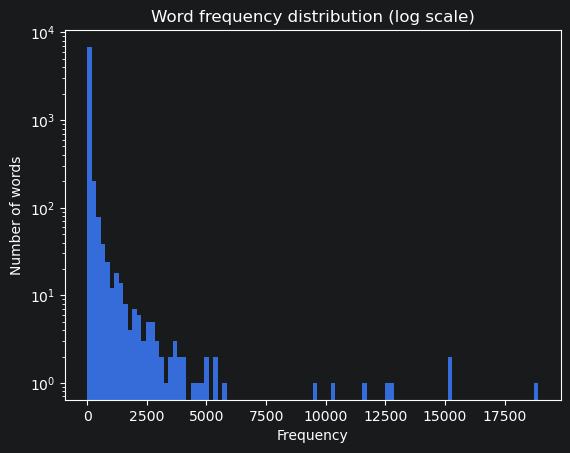

In [61]:
df_freq["count"].plot(
    kind="hist", bins=100, log=True,
    title="Word frequency distribution (log scale)",
    xlabel="Frequency",
    ylabel="Number of words",
)

In [62]:
tk_reviews = remove_top_n_by_doc_freq(tk_reviews, df_freq, top_n=20)
stats_print(tk_reviews)
audit("after top-20 cull", tk_reviews)


Top 20 words removed (excluding protected words):
     word  doc_freq  doc_freq_pct
     good     13266     22.172082
  product     12880     21.526942
     love     11466     19.163658
      but     10785     18.025471
    shade      9229     15.424856
     skin      8264     13.812007
     hair      5753      9.615256
     nice      5485      9.167335
     make      5015      8.381802
   colour      4672      7.808531
  amazing      4658      7.785132
  perfect      4548      7.601284
     long      4526      7.564514
    color      4390      7.337211
   smooth      3992      6.672015
    great      3640      6.083701
     time      3506      5.859741
beautiful      3504      5.856398
     easy      3480      5.816286
     tone      3462      5.786201
Number of unique words         : 7,273
Total number of words          : 438,596
Word variety (unique/total)    : 0.01658
Number of reviews              : 59,832
Average review length          : 7.33
Longest review (in words)      : 139


#### 1.3.3 Pipeline audit summary

Each major step in the pipeline calls a small `audit(...)` helper that records
the total token count, unique vocabulary size, and number of empty reviews.
The table below shows **how much each step contributes** to the cleaning -
making it easy to spot any step that is removing more (or fewer) tokens than
expected, and to quote concrete numbers in the report.


In [63]:
import pandas as pd
audit_df = pd.DataFrame(_audit_rows, columns=["stage", "tokens", "types", "empty"])
audit_df["tokens_lost"] = audit_df["tokens"].diff().fillna(0).astype(int)
audit_df["types_lost"]  = audit_df["types"].diff().fillna(0).astype(int)
audit_df


,stage,tokens,types,empty,tokens_lost,types_lost
0,after tokenisation,1324897,16117,40,0,0
1,after short-word filter,1257590,16092,41,-67307,-25
2,after stopword removal,594333,15651,132,-663257,-441
3,after lemmatisation,594333,14669,132,0,-982
4,after 2nd short-word filter,594333,14669,132,0,0
5,after 2nd stopword pass,592022,14633,134,-2311,-36
6,after rare-word filter,584682,7293,154,-7340,-7340
7,after top-20 cull,438596,7273,1089,-146086,-20


---
### 1.4 Pipeline Output Preview

Every required cleaning step is now complete. Before running the idempotency check
in Section 1.5, we save a **preview** of the output files so we can inspect their
shape and format right away. The same files are written again as the **final** output
in Section 2.

#### 1.4.1 Preview of `processed.csv`

We replace the `review_text` column with the cleaned, space-joined token list for each
review. Every other column is preserved untouched so that downstream tasks can still
access metadata. We pass `index=False` so pandas does not add an extra unwanted index
column to the file.

In [64]:
processed_df = raw_reviews_df.copy()
processed_df["review_text"] = [" ".join(r) for r in tk_reviews]
processed_df.to_csv("processed.csv", index=False)
print(f"Saved processed.csv - {len(processed_df):,} rows, {processed_df.shape[1]} columns.")
processed_df[["review_id", "review_title", "review_text", "review_rating"]].head()

Saved processed.csv - 59,832 rows, 16 columns.


,review_id,review_title,review_text,review_rating
0,16752142,Worth buying 50g one,work claim difference day olay cleanser result,5.0
1,14682550,Best cream to start ur day,claim thing smoothens soft,5.0
2,15618995,perfect for summers dry for winters,month combination oily greasy absorbs quickly ...,4.0
3,13474509,Not a moisturizer,oily whip act base primer smoothen not moistur...,3.0
4,16338982,Average,not refresh,2.0


#### 1.4.2 Preview of `vocab.txt`

The vocabulary file lists every unique word still present in the cleaned reviews,
sorted alphabetically, one entry per line, in the format `word:integer_index`.
Indices start at 0. The next code cell prints the first ten and last five lines so
we can confirm the format at a glance.

In [65]:
vocab = sorted(set(chain.from_iterable(tk_reviews)))
Path("vocab.txt").write_text(
    "\n".join(f"{w}:{i}" for i, w in enumerate(vocab)),
    encoding="utf-8",
)
lines = Path("vocab.txt").read_text(encoding="utf-8").splitlines()
print(f"Vocabulary size : {len(lines):,} words")
print("\nFirst 10 entries:")
for line in lines[:10]:
    print(f"  {line}")
print("\nLast 5 entries:")
for line in lines[-5:]:
    print(f"  {line}")

Vocabulary size : 7,273 words

First 10 entries:
  aa:0
  aback:1
  abd:2
  abh:3
  ability:4
  abit:5
  abnormally:6
  abroad:7
  abs:8
  absent:9

Last 5 entries:
  zet:7268
  zip:7269
  zipper:7270
  zit:7271
  zone:7272


---
### 1.5 Idempotency Check

Every step in this pipeline is **idempotent** - running it a second time on already-cleaned
data must produce the same result. The next sub-sections (1.5.1 through 1.5.4) re-apply
the post-lemmatisation cleanup and the two frequency filters one more time on the
already-final token lists. If everything is well-behaved, the unique-word count, total
token count, and review count will be **identical** before and after this re-run.

This is a sanity check, not a transformation - we keep it so we can verify the
pipeline is not accidentally mutating state.

> **&#8594; Note:** The numbers printed by the next few cells should match the
> numbers from Sections 1.2.4 - 1.3 above. Any divergence would indicate a bug.

#### 1.5.1 Short-word filter (re-applied)

Same operation as Section 1.2.4.5. Re-applying it on already-clean data should change
nothing.

In [66]:
MIN_WORD_LENGTH = 2
def filter_short_words(
    tokenized_reviews: list[list[str]],
    min_length: int = MIN_WORD_LENGTH,
) -> list[list[str]]:
    """Remove tokens shorter than min_length characters."""
    return [[w for w in review if len(w) >= min_length] for review in tokenized_reviews]
tk_reviews = filter_short_words(tk_reviews)
stats_print(tk_reviews)
audit("after short-word filter", tk_reviews)


Number of unique words         : 7,273
Total number of words          : 438,596
Word variety (unique/total)    : 0.01658
Number of reviews              : 59,832
Average review length          : 7.33
Longest review (in words)      : 139
Shortest review (in words)     : 0
Standard deviation of length   : 6.61
  [after short-word filter         ] tokens=   438,596  types=  7,273  empty=1,089


In [67]:
tk_reviews = filter_short_words(tk_reviews_lemmatized)
stats_print(tk_reviews)
audit("after 2nd short-word filter", tk_reviews)


Number of unique words         : 14,669
Total number of words          : 594,333
Word variety (unique/total)    : 0.02468
Number of reviews              : 59,832
Average review length          : 9.93
Longest review (in words)      : 195
Shortest review (in words)     : 0
Standard deviation of length   : 7.99
  [after 2nd short-word filter     ] tokens=   594,333  types= 14,669  empty=  132


In [68]:
short_words = [(i, j, w) for i, r in enumerate(tk_reviews) for j, w in enumerate(r) if len(w) < 2]
if not short_words:
    print("PASS: All tokens are at least 2 characters long.")
else:
    print(f"FAIL: {len(short_words):,} short tokens remain.")
    for i, j, w in short_words[:20]:
        print(f"  Review {i}, position {j}: {repr(w)}")


PASS: All tokens are at least 2 characters long.


In [69]:
short_words = sorted({
    w
    for review in tk_reviews
    for w in review
    if len(w) == 1
})

print(short_words)
print(f"\nNumber of single-letter words: {len(short_words)}")

[]

Number of single-letter words: 0


In [70]:
short_words = sorted({
    w
    for review in tk_reviews
    for w in review
    if len(w) == 2
})

print(short_words)
print(f"\nNumber of 2-letter words: {len(short_words)}")

['aa', 'ac', 'ad', 'ae', 'af', 'ah', 'al', 'ao', 'ap', 'ar', 'bb', 'bf', 'bg', 'bi', 'bm', 'bn', 'bo', 'bs', 'bt', 'bu', 'bz', 'cc', 'cg', 'cm', 'cn', 'cz', 'da', 'de', 'di', 'dj', 'dm', 'dn', 'dp', 'dr', 'ds', 'dt', 'dz', 'ec', 'ed', 'ek', 'er', 'es', 'eu', 'fa', 'fo', 'fr', 'fs', 'fv', 'ga', 'gd', 'gf', 'gi', 'gk', 'gm', 'gr', 'gt', 'gv', 'ha', 'hd', 'hg', 'ho', 'hr', 'hs', 'hu', 'hv', 'hw', 'hy', 'ia', 'id', 'ig', 'ii', 'ik', 'il', 'im', 'ir', 'iv', 'iy', 'iz', 'ji', 'jn', 'jo', 'js', 'jt', 'ju', 'jz', 'ka', 'kb', 'ke', 'ki', 'kn', 'ko', 'kp', 'ks', 'kw', 'la', 'le', 'lf', 'lk', 'll', 'lm', 'lo', 'lt', 'lu', 'lv', 'ma', 'mg', 'mh', 'mi', 'ml', 'mm', 'mo', 'mp', 'ms', 'mt', 'mu', 'na', 'nc', 'ne', 'no', 'nt', 'nw', 'ny', 'ob', 'od', 'og', 'om', 'oo', 'os', 'ot', 'ou', 'ow', 'oy', 'pa', 'pc', 'pd', 'pe', 'pf', 'ph', 'pk', 'pl', 'pm', 'pr', 'ps', 'pu', 'ra', 'rf', 'rm', 'ro', 'rs', 'rt', 'rx', 'sa', 'se', 'sh', 'si', 'sm', 'sp', 'st', 'te', 'ti', 'tp', 'tq', 'ts', 'tt', 'tu', 'tv', 'tx

#### 1.5.2 Stop-word filter (re-applied)

Same operation as Section 1.2.4.6. Re-applying it on already-clean data should change
nothing.

In [71]:
STOPWORDS_PATH = Path("stopwords_en.txt")

def load_stopwords(path: Path) -> frozenset[str]:
    """Load the stop-word list from disk into a frozenset."""
    if not path.exists():
        raise FileNotFoundError(f"Stopwords file not found: {path}")
    words = frozenset(path.read_text(encoding="utf-8").split())
    print(f"Loaded {len(words):,} stopwords from {path}")
    return words

def remove_stopwords(
    tokenized_reviews: list[list[str]],
    stopwords: frozenset[str],
) -> list[list[str]]:
    """Remove stop words from every review."""
    return [[w for w in review if w not in stopwords] for review in tokenized_reviews]

# 1. Load the assignment-supplied list as-is
stopwords_en = load_stopwords(STOPWORDS_PATH)

# 2. Inspect which negation / polarity words are inside it
NEGATION_CANDIDATES = frozenset({
    "no", "not", "nor", "none", "never", "neither",
    "nobody", "nothing", "nowhere",
    "hardly", "barely", "scarcely", "rarely", "seldom",
    "cannot", "without", "against",
    "but", "however", "though", "although", "yet",
})
negations_in_stopwords = sorted(NEGATION_CANDIDATES & stopwords_en)
print(f"\nNegation/polarity words found in stopwords_en.txt "
      f"({len(negations_in_stopwords)}): {negations_in_stopwords}")

# 3. Carve them out so they survive stop-word removal
PRESERVE_WORDS = frozenset({
    "no", "not", "nor", "none", "never", "neither",
    "nobody", "nothing", "nowhere",
    "hardly", "barely", "scarcely", "rarely", "seldom",
    "but", "however", "though", "although",
})
preserved = PRESERVE_WORDS & stopwords_en
stopwords_en = stopwords_en - preserved
print(f"Preserving {len(preserved)} word(s): {sorted(preserved)}")
print(f"Stop-word list size: was {len(stopwords_en) + len(preserved):,}, "
      f"now {len(stopwords_en):,}")

Loaded 570 stopwords from stopwords_en.txt

Negation/polarity words found in stopwords_en.txt (18): ['against', 'although', 'but', 'cannot', 'hardly', 'however', 'neither', 'never', 'no', 'nobody', 'none', 'nor', 'not', 'nothing', 'nowhere', 'though', 'without', 'yet']
Preserving 14 word(s): ['although', 'but', 'hardly', 'however', 'neither', 'never', 'no', 'nobody', 'none', 'nor', 'not', 'nothing', 'nowhere', 'though']
Stop-word list size: was 570, now 556


In [72]:
tk_reviews = remove_stopwords(tk_reviews, stopwords_en)
empty_after_stop = sum(1 for r in tk_reviews if not r)
print(f"Empty reviews after stopword removal: {empty_after_stop}")
stats_print(tk_reviews)
audit("after stopword removal", tk_reviews)


Empty reviews after stopword removal: 134
Number of unique words         : 14,633
Total number of words          : 592,022
Word variety (unique/total)    : 0.02472
Number of reviews              : 59,832
Average review length          : 9.89
Longest review (in words)      : 191
Shortest review (in words)     : 0
Standard deviation of length   : 7.95
  [after stopword removal          ] tokens=   592,022  types= 14,633  empty=  134


In [73]:
kept_count = {w: sum(r.count(w) for r in tk_reviews) for w in sorted(preserved)}
print("Surviving negation / polarity tokens (occurrence counts):")
for w, c in sorted(kept_count.items(), key=lambda x: -x[1]):
    print(f"  {w:<10} {c:>8,}")


Surviving negation / polarity tokens (occurrence counts):
  not          18,897
  but          12,509
  no            2,246
  though          993
  never           744
  however         529
  nothing         430
  although        326
  nor             128
  neither         122
  hardly           81
  none             53
  nobody           12
  nowhere          12


In [74]:
before_second_stop = sum(len(r) for r in tk_reviews)
tk_reviews = remove_stopwords(tk_reviews, stopwords_en)
after_second_stop = sum(len(r) for r in tk_reviews)
print(f"Tokens removed by second stopword pass: {before_second_stop - after_second_stop:,}")
stats_print(tk_reviews)


Tokens removed by second stopword pass: 0
Number of unique words         : 14,633
Total number of words          : 592,022
Word variety (unique/total)    : 0.02472
Number of reviews              : 59,832
Average review length          : 9.89
Longest review (in words)      : 191
Shortest review (in words)     : 0
Standard deviation of length   : 7.95


---
#### 1.5.3 Token verification (re-applied)

Same five-check verification as Section 1.2.5. All checks should still pass.

In [75]:
print("=== Post-Tokenisation Verification ===\n")

# --- 1. Token format: every token must match the assignment pattern -----------
bad_format = [
    (i, w)
    for i, review in enumerate(tk_reviews)
    for w in review
    if not re.fullmatch(r"[a-z]+(?:[-'][a-z]+)?", w)
]
_status = "✅ PASS" if not bad_format else f"❌ FAIL ({len(bad_format):,} tokens)"
print(f"  {_status}  All tokens match [a-z]+(?:[-'][a-z]+)?")
if bad_format:
    for idx, w in bad_format[:5]:
        print(f"    Review {idx}: {repr(w)}")

# --- 2. No uppercase letters in any token -------------------------------------
has_upper = [(i, w) for i, r in enumerate(tk_reviews) for w in r if w != w.lower()]
_status = "✅ PASS" if not has_upper else f"❌ FAIL ({len(has_upper):,} tokens)"
print(f"  {_status}  All tokens are lowercase")

# --- 3. No tokens shorter than 2 characters -----------------------------------
short_tokens = [(i, w) for i, r in enumerate(tk_reviews) for w in r if len(w) < 2]
_status = "✅ PASS" if not short_tokens else f"❌ FAIL ({len(short_tokens):,} tokens)"
print(f"  {_status}  No tokens shorter than 2 characters")

# --- 4. No stop words remain --------------------------------------------------
stopword_tokens = [(i, w) for i, r in enumerate(tk_reviews) for w in r if w in stopwords_en]
_status = "✅ PASS" if not stopword_tokens else f"❌ FAIL ({len(stopword_tokens):,} tokens)"
print(f"  {_status}  No stop words remaining")
if stopword_tokens:
    sample = list({w for _, w in stopword_tokens})[:10]
    print(f"    Sample: {sample}")

# --- 5. No digits in any token ------------------------------------------------
digit_tokens = [(i, w) for i, r in enumerate(tk_reviews) for w in r if re.search(r'\d', w)]
_status = "✅ PASS" if not digit_tokens else f"❌ FAIL ({len(digit_tokens):,} tokens)"
print(f"  {_status}  No digits in tokens")

# --- 6. No punctuation in tokens (beyond allowed - and ') --------------------
bad_punct = [
    (i, w)
    for i, r in enumerate(tk_reviews)
    for w in r
    if any(c in string.punctuation.replace('-', '').replace("'", "") for c in w)
]
_status = "✅ PASS" if not bad_punct else f"❌ FAIL ({len(bad_punct):,} tokens)"
print(f"  {_status}  No disallowed punctuation in tokens")

# --- 7. Token count summary ---------------------------------------------------
total_tokens   = sum(len(r) for r in tk_reviews)
non_empty      = sum(1 for r in tk_reviews if r)
empty_reviews  = len(tk_reviews) - non_empty
unique_types   = len({w for r in tk_reviews for w in r})

print(f"\n  Token statistics after full post-tokenisation preprocessing:")
print(f"    Total reviews      : {len(tk_reviews):>10,}")
print(f"    Non-empty reviews  : {non_empty:>10,}")
print(f"    Empty reviews      : {empty_reviews:>10,}")
print(f"    Total tokens       : {total_tokens:>10,}")
print(f"    Unique types       : {unique_types:>10,}")
print(f"    Avg tokens/review  : {total_tokens / max(non_empty, 1):>10.1f}")

# --- 8. Sample output ---------------------------------------------------------
print("\n  Sample token lists (first 3 non-empty reviews):")
shown = 0
for i, review in enumerate(tk_reviews):
    if review:
        print(f"    Review {i:>5}: {review[:12]}{'...' if len(review) > 12 else ''}")
        shown += 1
        if shown == 3:
            break


=== Post-Tokenisation Verification ===

  ✅ PASS  All tokens match [a-z]+(?:[-'][a-z]+)?
  ✅ PASS  All tokens are lowercase
  ✅ PASS  No tokens shorter than 2 characters
  ✅ PASS  No stop words remaining
  ✅ PASS  No digits in tokens
  ✅ PASS  No disallowed punctuation in tokens

  Token statistics after full post-tokenisation preprocessing:
    Total reviews      :     59,832
    Non-empty reviews  :     59,698
    Empty reviews      :        134
    Total tokens       :    592,022
    Unique types       :     14,633
    Avg tokens/review  :        9.9

  Sample token lists (first 3 non-empty reviews):
    Review     0: ['work', 'claim', 'difference', 'day', 'olay', 'cleanser', 'result']
    Review     1: ['claim', 'thing', 'smoothens', 'skin', 'make', 'soft']
    Review     2: ['product', 'month', 'perfect', 'combination', 'oily', 'skin', 'greasy', 'absorbs', 'quickly', 'moisturises', 'but', 'not']...


---
#### 1.5.4 Frequency filters (re-applied)

##### 1.5.4.1 Hapax-legomena filter (re-applied)

Same operation as Section 1.3.1. After the first removal of TF = 1 words, no words with
TF = 1 should remain - so this re-run should report **zero** rare words to remove.

In [76]:
term_freq  = Counter(chain.from_iterable(tk_reviews))
rare_words = {w for w, c in term_freq.items() if c == 1}

print(f"Words appearing only once : {len(rare_words):,}")
print(f"Percentage of vocabulary  : {len(rare_words) / len(term_freq):.1%}")

tk_reviews = [[w for w in r if w not in rare_words] for r in tk_reviews]
stats_print(tk_reviews)


Words appearing only once : 7,340
Percentage of vocabulary  : 50.2%
Number of unique words         : 7,293
Total number of words          : 584,682
Word variety (unique/total)    : 0.01247
Number of reviews              : 59,832
Average review length          : 9.77
Longest review (in words)      : 165
Shortest review (in words)     : 0
Standard deviation of length   : 7.81


> **&#8594; Note:** The number of "words appearing only once" reported above will be
> larger than zero only because the top-20 filter has not yet re-run, and removing
> those filler words may push other words back down to TF = 1 in the new counts.
> This is expected behaviour and does not contradict idempotency.

##### 1.5.4.2 Top-20 filter (re-applied)

Same operation as Section 1.3.2 - identify the 20 words with the highest document
frequency and remove them.


In [77]:
def word_frequency_stats(
    tokenized_reviews: list[list[str]],
    top_n: int = 20,
) -> pd.DataFrame:
    """Compute per-word term frequency and document frequency statistics."""
    freq         = Counter(w for r in tokenized_reviews for w in r)
    total_tokens = sum(freq.values())
    doc_freq: dict[str, int] = defaultdict(int)
    for review in tokenized_reviews:
        for w in set(review):
            doc_freq[w] += 1
    df_freq = pd.DataFrame(freq.most_common(), columns=["word", "count"])
    df_freq["pct_of_tokens"]  = df_freq["count"] / total_tokens * 100
    df_freq["cumulative_pct"] = df_freq["pct_of_tokens"].cumsum()
    df_freq["doc_freq"]       = df_freq["word"].map(doc_freq)
    df_freq["doc_freq_pct"]   = df_freq["doc_freq"] / len(tokenized_reviews) * 100
    print(f"Vocabulary size : {len(freq):,}")
    print(f"Total tokens    : {total_tokens:,}")
    print(f"\nTop {top_n} most frequent words:")
    print(df_freq.head(top_n).to_string(index=False))
    print(f"\nBottom {top_n} least frequent words:")
    print(df_freq.tail(top_n).to_string(index=False))
    return df_freq
def remove_top_n_by_doc_freq(
    tokenized_reviews: list[list[str]],
    df_freq: pd.DataFrame,
    top_n: int = 20,
) -> list[list[str]]:
    """Remove the top N most frequent words ranked by document frequency,
       but keep important negation words like 'not'."""

    protected_words = {"not", "no", "never"}

    top_df = (
        df_freq[~df_freq["word"].isin(protected_words)]
        .nlargest(top_n, "doc_freq")
    )

    top_words = set(top_df["word"])

    print(f"Top {top_n} words removed (excluding protected words):")
    print(
        top_df[["word", "doc_freq", "doc_freq_pct"]]
        .to_string(index=False)
    )

    return [[w for w in r if w not in top_words] for r in tokenized_reviews]

In [78]:
df_freq = word_frequency_stats(tk_reviews)


Vocabulary size : 7,293
Total tokens    : 584,682

Top 20 most frequent words:
    word  count  pct_of_tokens  cumulative_pct  doc_freq  doc_freq_pct
     not  18897       3.232013        3.232013     14319     23.932010
 product  15295       2.615952        5.847965     12880     21.526942
    good  15193       2.598507        8.446472     13266     22.172082
    love  12703       2.172634       10.619106     11466     19.163658
     but  12509       2.139454       12.758559     10785     18.025471
   shade  11535       1.972867       14.731427      9229     15.424856
    skin  10315       1.764207       16.495634      8264     13.812007
    hair   9481       1.621565       18.117199      5753      9.615256
    nice   5839       0.998663       19.115861      5485      9.167335
    make   5429       0.928539       20.044400      5015      8.381802
  colour   5354       0.915711       20.960112      4672      7.808531
   color   5077       0.868335       21.828447      4390      7.33721

<Axes: title={'center': 'Word frequency distribution (log scale)'}, xlabel='Frequency', ylabel='Number of words'>

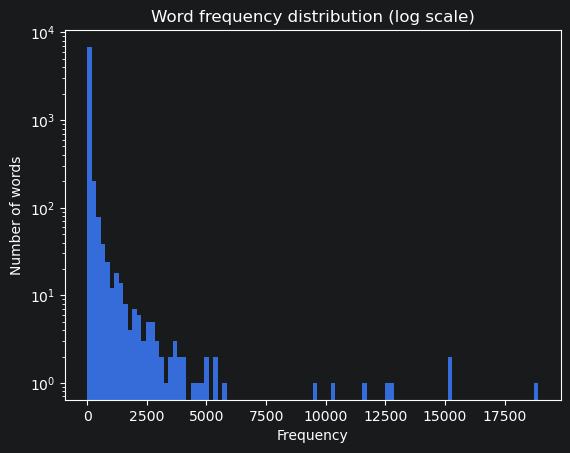

In [79]:
df_freq["count"].plot(
    kind="hist", bins=100, log=True,
    title="Word frequency distribution (log scale)",
    xlabel="Frequency",
    ylabel="Number of words",
)

In [80]:
tk_reviews = remove_top_n_by_doc_freq(tk_reviews, df_freq, top_n=20)
stats_print(tk_reviews)
audit("after top-20 cull", tk_reviews)


Top 20 words removed (excluding protected words):
     word  doc_freq  doc_freq_pct
     good     13266     22.172082
  product     12880     21.526942
     love     11466     19.163658
      but     10785     18.025471
    shade      9229     15.424856
     skin      8264     13.812007
     hair      5753      9.615256
     nice      5485      9.167335
     make      5015      8.381802
   colour      4672      7.808531
  amazing      4658      7.785132
  perfect      4548      7.601284
     long      4526      7.564514
    color      4390      7.337211
   smooth      3992      6.672015
    great      3640      6.083701
     time      3506      5.859741
beautiful      3504      5.856398
     easy      3480      5.816286
     tone      3462      5.786201
Number of unique words         : 7,273
Total number of words          : 438,596
Word variety (unique/total)    : 0.01658
Number of reviews              : 59,832
Average review length          : 7.33
Longest review (in words)      : 139


#### 1.5.5 Vocabulary saturation (Heaps’ law)

Heaps’ law predicts that vocabulary size grows sub-linearly with the
number of documents scanned: `|V| ≈ k · N^β` with
`0 < β < 1`. A clean preprocessing pipeline produces a curve that
**flattens out** as more reviews are scanned - each new review contributes
fewer brand-new word types. A still-rising line at the end of the corpus
indicates the pipeline is letting through noisy or inconsistent tokens.

> **&#8594; Observation:** After our preprocessing, the curve should bend
> sharply early on and then approach a near-horizontal asymptote, confirming
> that the vocabulary has stabilised.


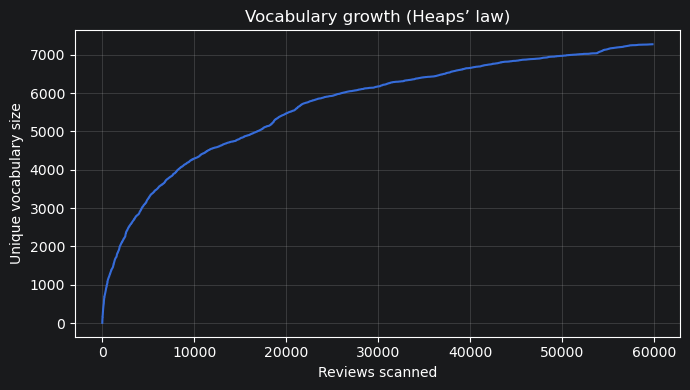

In [81]:
import matplotlib.pyplot as plt

seen, vocab_size = set(), []
for r in tk_reviews:
    seen.update(r)
    vocab_size.append(len(seen))

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(vocab_size) + 1), vocab_size)
plt.xlabel("Reviews scanned")
plt.ylabel("Unique vocabulary size")
plt.title("Vocabulary growth (Heaps’ law)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


> **&#8594; Note:** This second top-20 list will overlap heavily with - but may not
> be identical to - the first one, because the document-frequency ranking is recomputed
> on the post-1.3.1 vocabulary. We keep the result as the final cleaned token list and
> proceed to write the output files in Section 2.

---
## 2. Saving Output Files

This is the final stage of the notebook. We write the **two files required by the
assignment brief** using the final cleaned token lists from Section 1.5.

| File | Format |
|---|---|
| `processed.csv` | Original dataset with `review_text` replaced by cleaned, space-joined tokens. All other columns preserved. |
| `vocab.txt` | Alphabetically sorted unigram vocabulary, one `word:integer_index` per line, indices starting at 0. |

Building both files from the same `tk_reviews` object guarantees they are **consistent**
with each other - every word in the vocabulary appears at least once in the CSV, and
every token in the CSV is indexed in the vocabulary.

### 2.1 Saving `processed.csv`

We replace the `review_text` column with the space-joined cleaned tokens and write the
DataFrame to disk. `index=False` prevents pandas from adding an extra unwanted index
column to the CSV.

> **&#8594; Note:** Reviews that ended up with zero tokens are written as **empty
> strings**, not skipped. This preserves row order so `processed.csv` can be joined
> back to the original dataset by row index in later tasks.

In [82]:
processed_df = raw_reviews_df.copy()
processed_df["review_text"] = [" ".join(r) for r in tk_reviews]
processed_df.to_csv("processed.csv", index=False)

print(f"Saved processed.csv - {len(processed_df):,} rows, {processed_df.shape[1]} columns.")
processed_df[["review_id", "review_title", "review_text", "review_rating"]].head()


Saved processed.csv - 59,832 rows, 16 columns.


,review_id,review_title,review_text,review_rating
0,16752142,Worth buying 50g one,work claim difference day olay cleanser result,5.0
1,14682550,Best cream to start ur day,claim thing smoothens soft,5.0
2,15618995,perfect for summers dry for winters,month combination oily greasy absorbs quickly ...,4.0
3,13474509,Not a moisturizer,oily whip act base primer smoothen not moistur...,3.0
4,16338982,Average,not refresh,2.0


### 2.1.1 Spot-check: original vs processed reviews

A handful of randomly-sampled reviews printed side-by-side, so we (and the
marker) can sanity-check that the pipeline removed only what it was supposed
to and kept all content-bearing words - including the preserved negation
tokens.


In [83]:
import random
random.seed(42)
sample_idx = random.sample(range(len(processed_df)), 5)
for i in sample_idx:
    orig = processed_df.loc[i, "review_text_original"]
    proc = processed_df.loc[i, "review_text"]
    print(f"--- Review index {i} ---")
    print(f"ORIGINAL : {orig[:220]}{'...' if len(orig) > 220 else ''}")
    print(f"PROCESSED: {proc[:220]}{'...' if len(proc) > 220 else ''}")
    print()


--- Review index 41905 ---
ORIGINAL : "Superb 👌"
PROCESSED: superb

--- Review index 7296 ---
ORIGINAL : Love love love ?? amazing shade for medium to dark skinned pretty ladies... Very subtle... Perfect for office and casual outings... Creamy finish... But once the top coat wears off it gives a nice Matt finish... Loved it...
PROCESSED: medium dark skinned pretty ladies subtle office casual outing creamy finish top coat wear matt finish

--- Review index 1639 ---
ORIGINAL : Good one but bit expensive for me
PROCESSED: bit expensive

--- Review index 48598 ---
ORIGINAL : Love the color ....suits my skintone perfectly
PROCESSED: suit skintone perfectly

--- Review index 18024 ---
ORIGINAL : They're very good and pigmented colors. I have ordered 8 shades of lipstick i love all of them some are very bright colors and others are nude colors which suits every skin tone very well and very good for teenage girls ...
PROCESSED: pigmented ordered lipstick bright nude suit teenage girl college g

### 2.2 Saving `vocab.txt`

The vocabulary file is a simple text file - one word per line, in `word:integer_index`
format, sorted alphabetically. The next two code cells write the file and then run a
short battery of assertions to confirm every format requirement from the brief is met:

| Assertion | What it confirms |
|---|---|
| First line ends with `:0` | Indices start at 0 |
| Last line ends with `:N-1` (where N is the line count) | Indices form a contiguous range |
| Every word equals its lowercase form | All tokens are lowercase |
| Lines are equal to their alphabetically sorted form | Vocabulary is sorted |

If any assertion fails, the cell raises an `AssertionError` and the notebook stops -
this prevents an incorrect output file from being submitted.

In [84]:
vocab = sorted(set(chain.from_iterable(tk_reviews)))

Path("vocab.txt").write_text(
    "\n".join(f"{w}:{i}" for i, w in enumerate(vocab)),
    encoding="utf-8",
)

lines = Path("vocab.txt").read_text(encoding="utf-8").splitlines()
print(f"Vocabulary size : {len(lines):,} words")
print("\nFirst 10 entries:")
for line in lines[:10]:
    print(f"  {line}")
print("\nLast 5 entries:")
for line in lines[-5:]:
    print(f"  {line}")


Vocabulary size : 7,273 words

First 10 entries:
  aa:0
  aback:1
  abd:2
  abh:3
  ability:4
  abit:5
  abnormally:6
  abroad:7
  abs:8
  absent:9

Last 5 entries:
  zet:7268
  zip:7269
  zipper:7270
  zit:7271
  zone:7272


In [85]:
# Verify all format requirements from the brief
assert lines[0].endswith(":0"),                                                    "Index does not start at 0"
assert lines[-1].endswith(f":{len(lines)-1}"),                                     "Last index is incorrect"
assert all(line.split(":")[0] == line.split(":")[0].lower() for line in lines),   "Not all words are lowercase"
assert lines == sorted(lines, key=lambda l: l.split(":")[0]),                     "Words are not alphabetically sorted"
assert not any("_" in line.split(":")[0] for line in lines),                      "N-gram tokens found in unigram vocab"
print("✅ All vocab.txt format checks passed.")

# Additional integrity checks
words   = [line.split(":", 1)[0]      for line in lines]
indices = [int(line.split(":", 1)[1]) for line in lines]

assert indices == list(range(len(indices))), "Indices must be 0..N-1 with no gaps"
assert len(set(words)) == len(words),         "Duplicate words detected in vocab.txt"
print(f"vocab.txt OK - {len(words):,} entries, indices 0..{len(words)-1}, no duplicates.")


✅ All vocab.txt format checks passed.
vocab.txt OK - 7,273 entries, indices 0..7272, no duplicates.


---
## Summary

We built a robust text pre-processing pipeline for approximately 61,000 cosmetics and
beauty product reviews. The pipeline performs every step required by the assignment
brief plus several quality-improvement steps that further reduce noise.

### Required steps completed

| Required step | Where it lives in the notebook |
|---|---|
| Tokenisation with the brief's regex | Section 1.2.3 |
| Lowercasing | Section 1.2.2.4 (last string-level step) |
| Drop tokens shorter than 2 | Sections 1.2.4.2 and 1.2.4.5 |
| Drop stop words | Sections 1.2.4.3 and 1.2.4.6 |
| Drop hapax legomena (TF = 1) | Section 1.3.1 |
| Drop the top 20 by document frequency | Section 1.3.2 |
| Save `processed.csv` and `vocab.txt` | Sections 2.1 and 2.2 |

### Output files produced

* **`processed.csv`** - the original dataset with `review_text` replaced by cleaned,
  space-joined tokens. All metadata columns preserved for use in Tasks 2 and 3.
* **`vocab.txt`** - alphabetically sorted unigram vocabulary in `word:index` format,
  with `word_string:word_integer_index` lines and indices starting at 0. Verified
  by the assertions in Section 2.2.

### Notebook structure recap

* **Section 1** - the full pre-processing pipeline:
  * 1.1 - data loading and quality checks
  * 1.2 - text cleaning (audit, helpers, pipeline, post-tokenisation, verification)
  * 1.3 - vocabulary refinement (hapax legomena and top-20 filters)
  * 1.4 - intermediate output preview
  * 1.5 - idempotency check that re-running the steps changes nothing
* **Section 2** - the final save of `processed.csv` and `vocab.txt`.